<a href="https://colab.research.google.com/github/Kshitiz83/Credit-Risk-Assessment-Model-Evaluating-Loan-Applicants-with-Supervised-Learning/blob/main/Credit_Risk_Assessment_Model_Evaluating_Loan_Applicants_with_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


This cell imports essential Python libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), and machine learning (scikit-learn, statsmodels, imblearn). It also sets display options for pandas DataFrames and matplotlib plots, filters warnings, and loads the `lending_club_loan_two.csv` dataset into a DataFrame named `df`. Finally, it displays the first 3 rows of the loaded DataFrame.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None
plt.rcParams['figure.figsize']=(8,5)
from warnings import filterwarnings
filterwarnings('ignore')
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, precision_score,  recall_score, f1_score, classification_report, roc_curve, auc, precision_recall_curve,average_precision_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
#from xgboost import XGBClassifier
#from xgboost.xgbclassifier import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB

df=pd.read_csv('/content/lending_club_loan_two.csv')
df.head(3)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,Not Verified,1/15/2023,Fully Paid,vacation,Vacation,26.24,6/1/1990,16,0,36369,41.8,25,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,Not Verified,1/15/2023,Fully Paid,debt_consolidation,Debt consolidation,22.05,7/4/2023,17,0,20131,53.3,27,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,Source Verified,1/15/2023,Fully Paid,credit_card,Credit card refinancing,12.79,8/7/2023,13,0,11987,92.2,26,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"



This cell displays the data types of all columns in the `df` DataFrame. This is crucial for understanding the nature of the data and identifying columns that may require type conversion before analysis or modeling.

In [ ]:
df.dtypes

,0
loan_amnt,int64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_title,object
emp_length,object
home_ownership,object
annual_inc,float64



This cell outputs the shape of the DataFrame, showing the total number of rows and columns. This provides a quick overview of the dataset's dimensions.

In [ ]:
df.shape

(396030, 27)


This cell provides a concise summary of the DataFrame, including the column names, their non-null counts, and data types. It also shows the memory usage, helping to identify missing values and assess data quality.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  int64  
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  


This cell performs data cleaning and type conversion for specific columns: `term`, `emp_length`, and `int_rate`.
- For `term`, it removes ' months' and converts the column to numeric.
- For `emp_length`, it handles '10+ years' and '< 1 year' by converting them to numerical representations and then converts the entire column to numeric, filling `NaN` with '0 years' initially.
- For `int_rate`, it ensures the column is numeric.

In [ ]:
df['term'] = pd.to_numeric(df['term'].astype(str).str.replace(' months', ''), errors='coerce')
df['emp_length'] = df['emp_length'].fillna('0 years').astype(str)
df['emp_length'] = df['emp_length'].apply(lambda x: x.replace('10+ years', '10').replace('< 1 year', '0').replace(' years', '').replace(' year', ''))
df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')
df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')


After the previous data type conversions and cleaning, this cell re-displays the data types of all columns to confirm the changes have been applied correctly.

In [ ]:
df.dtypes

,0
loan_amnt,int64
term,int64
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_title,object
emp_length,int64
home_ownership,object
annual_inc,float64



This cell calculates and displays the sum of null (missing) values for each column in the DataFrame. This helps in identifying columns with missing data and planning appropriate imputation or removal strategies.

In [ ]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,22927
emp_length,0
home_ownership,0
annual_inc,0



Based on the analysis of missing values or irrelevance, this cell drops the 'emp_title' and 'title' columns from the DataFrame in-place. These columns likely contained too many unique values or were not deemed useful for the model.

In [ ]:
df.drop(columns=['emp_title','title'],inplace=True)


After dropping the 'emp_title' and 'title' columns, this cell displays the first 3 rows of the modified DataFrame to show the updated structure.

In [ ]:
df.head(3)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000,36,11.44,329.48,B,B4,10,RENT,117000.0,Not Verified,1/15/2023,Fully Paid,vacation,26.24,6/1/1990,16,0,36369,41.8,25,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000,36,11.99,265.68,B,B5,4,MORTGAGE,65000.0,Not Verified,1/15/2023,Fully Paid,debt_consolidation,22.05,7/4/2023,17,0,20131,53.3,27,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600,36,10.49,506.97,B,B3,0,RENT,43057.0,Source Verified,1/15/2023,Fully Paid,credit_card,12.79,8/7/2023,13,0,11987,92.2,26,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"



This cell further refines the DataFrame by dropping the 'initial_list_status' column in-place. It then displays the first 3 rows to show the DataFrame after this modification.

In [ ]:
df.drop(columns=['initial_list_status'],inplace=True)
df.head(3)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000,36,11.44,329.48,B,B4,10,RENT,117000.0,Not Verified,1/15/2023,Fully Paid,vacation,26.24,6/1/1990,16,0,36369,41.8,25,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000,36,11.99,265.68,B,B5,4,MORTGAGE,65000.0,Not Verified,1/15/2023,Fully Paid,debt_consolidation,22.05,7/4/2023,17,0,20131,53.3,27,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600,36,10.49,506.97,B,B3,0,RENT,43057.0,Source Verified,1/15/2023,Fully Paid,credit_card,12.79,8/7/2023,13,0,11987,92.2,26,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"



Following additional column drops, this cell re-checks and displays the sum of null values for each remaining column, providing an updated status of missing data.

In [ ]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,0
home_ownership,0
annual_inc,0
verification_status,0



This cell re-displays the data types of all columns in the DataFrame after several cleaning and dropping operations, ensuring the current state of column types is understood.

In [ ]:
df.dtypes

,0
loan_amnt,int64
term,int64
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_length,int64
home_ownership,object
annual_inc,float64
verification_status,object



This cell categorizes the DataFrame columns into numerical and categorical types based on their `dtype`. It then prints the `Index` of columns for each category, which is useful for subsequent data processing steps like visualization, scaling, or encoding.

In [ ]:
num_cols=df.select_dtypes(include=np.number).columns
cate_cols=df.select_dtypes(include='object').columns
print(num_cols)
print(cate_cols)

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length',
       'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'mort_acc', 'pub_rec_bankruptcies'],
      dtype='object')
Index(['grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'loan_status', 'purpose', 'earliest_cr_line',
       'application_type', 'address'],
      dtype='object')



This cell generates box plots for all numerical columns identified earlier. The plots are arranged in a multi-panel figure, providing a visual summary of each numerical feature's distribution, median, quartiles, and potential outliers.

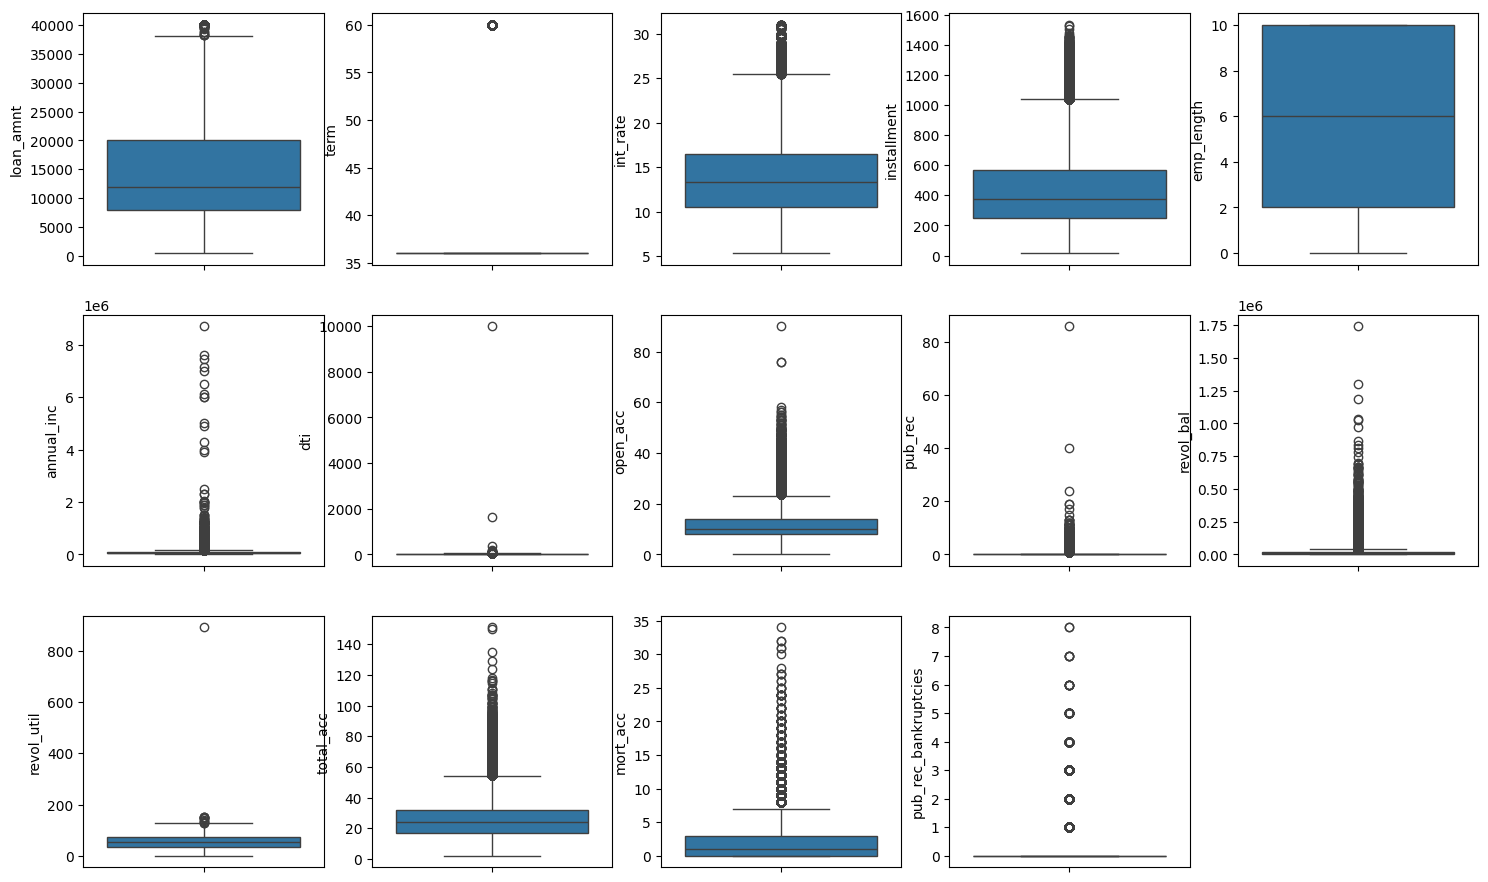

In [ ]:
t=1
plt.figure(figsize=(18,15))
for i in num_cols:
    plt.subplot(4,5,t)
    sns.boxplot(df[i])
    plt.xticks(rotation=90)
    t+=1


This cell iterates through each numerical column and generates a distribution plot (histogram with KDE). These plots help in understanding the shape of the data distribution for each numerical feature, including skewness and modality.

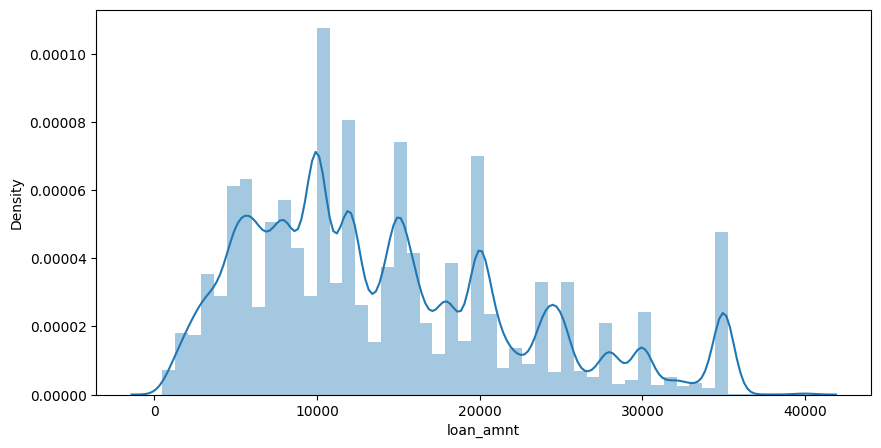

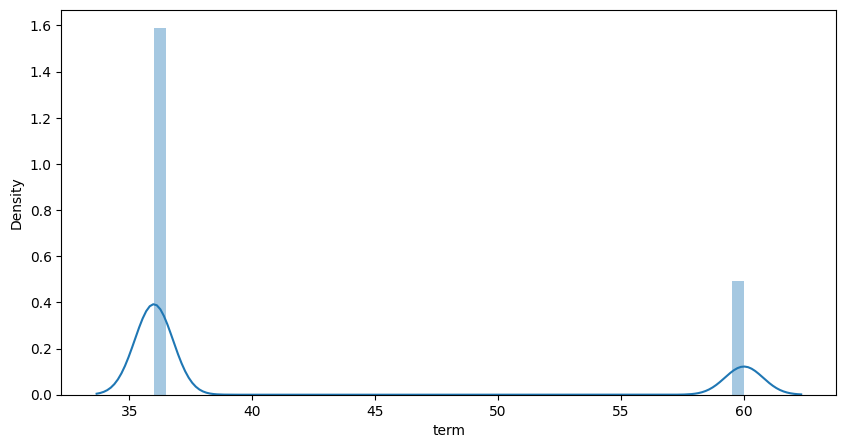

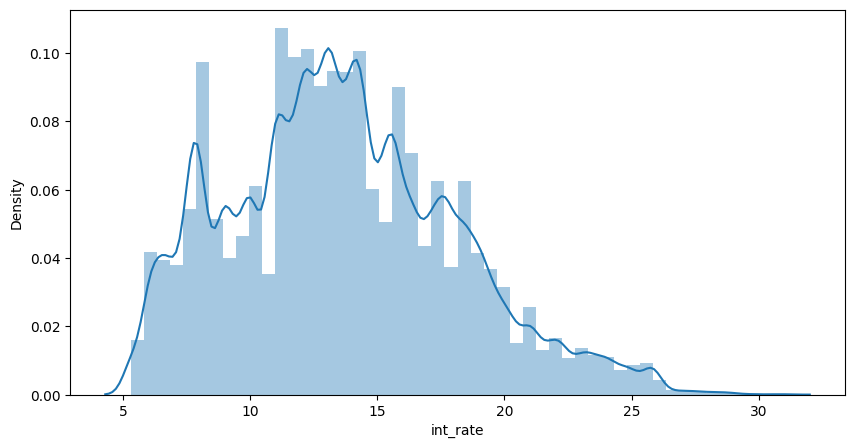

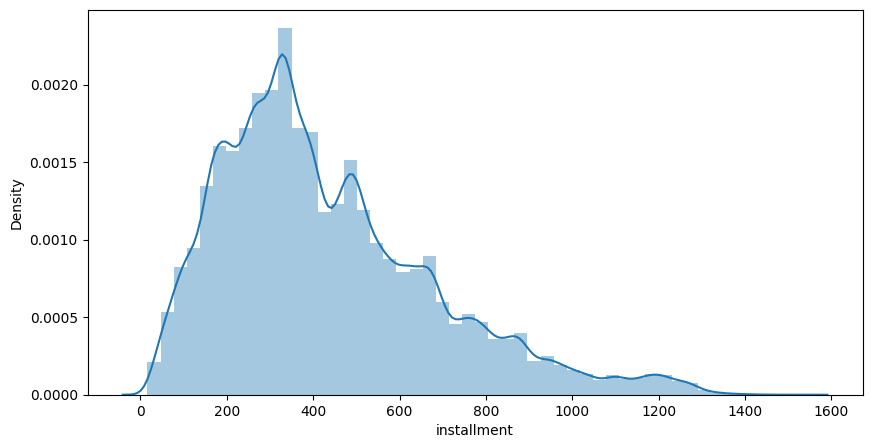

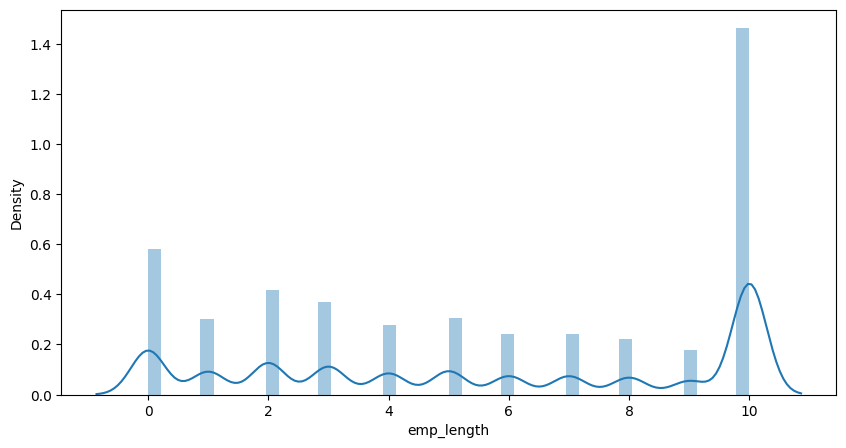

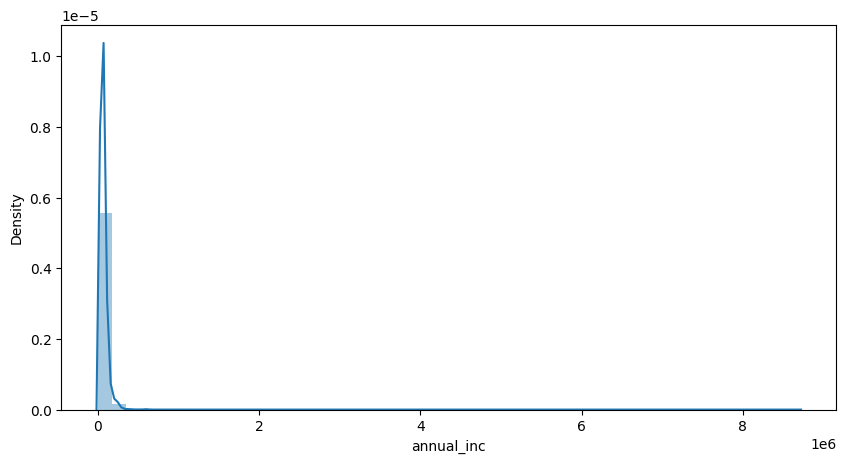

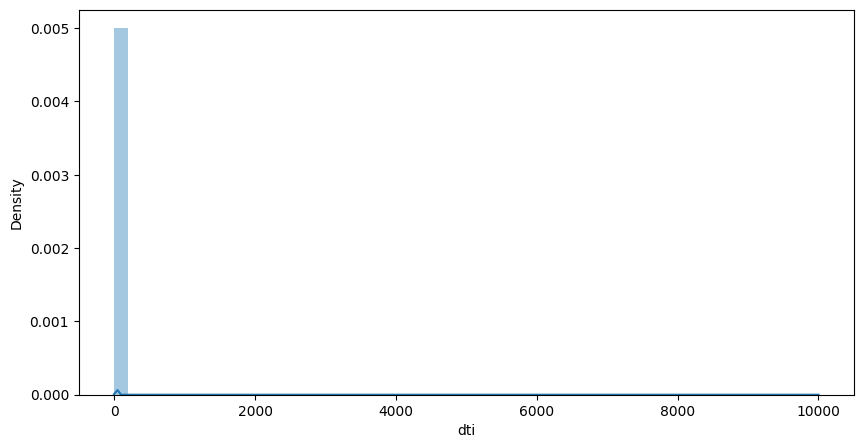

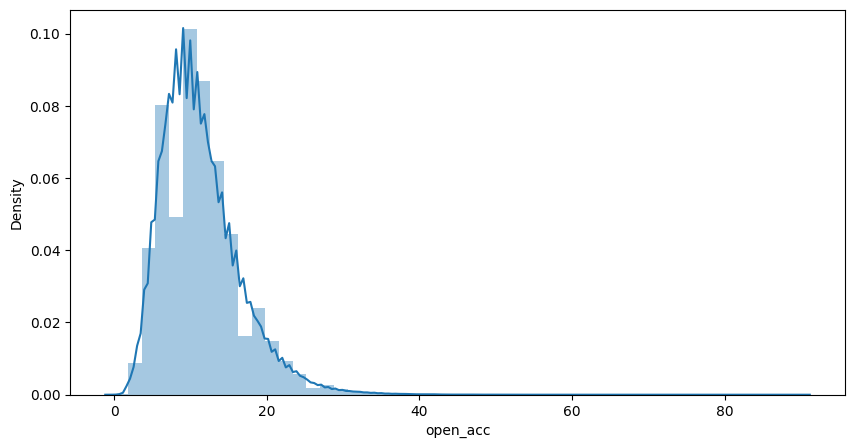

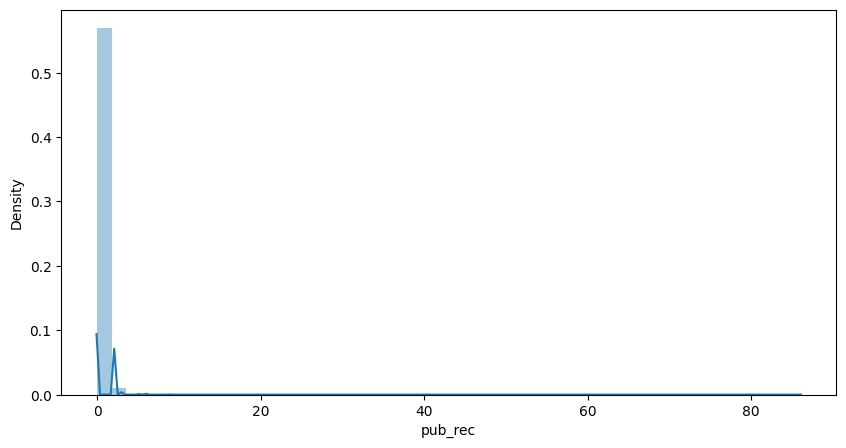

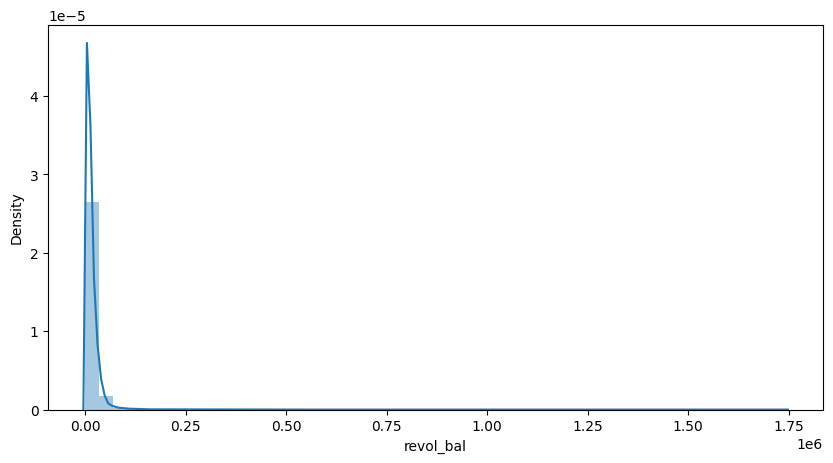

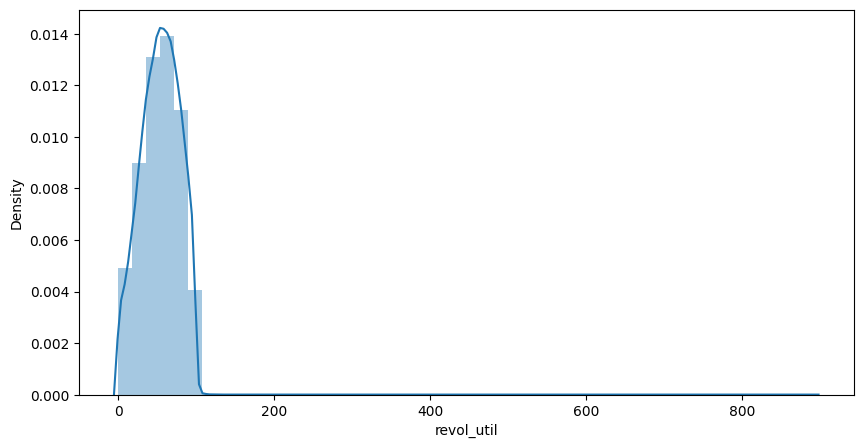

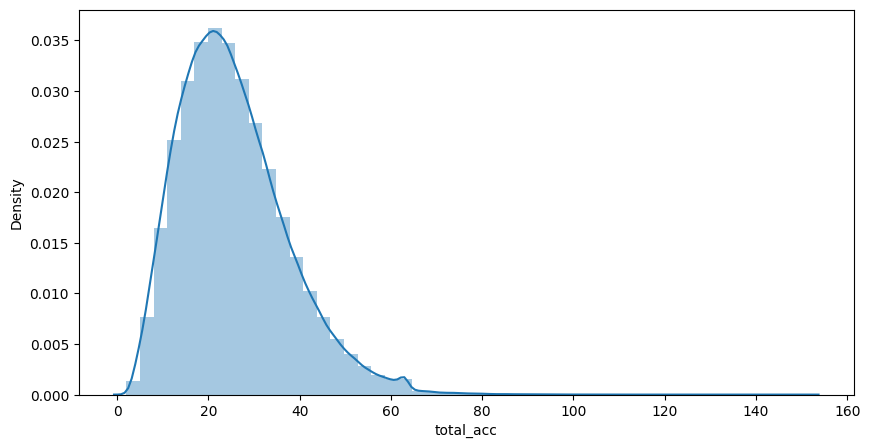

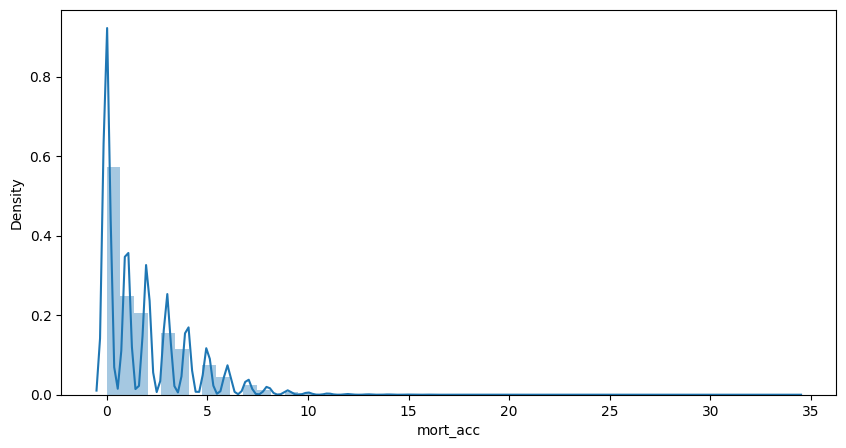

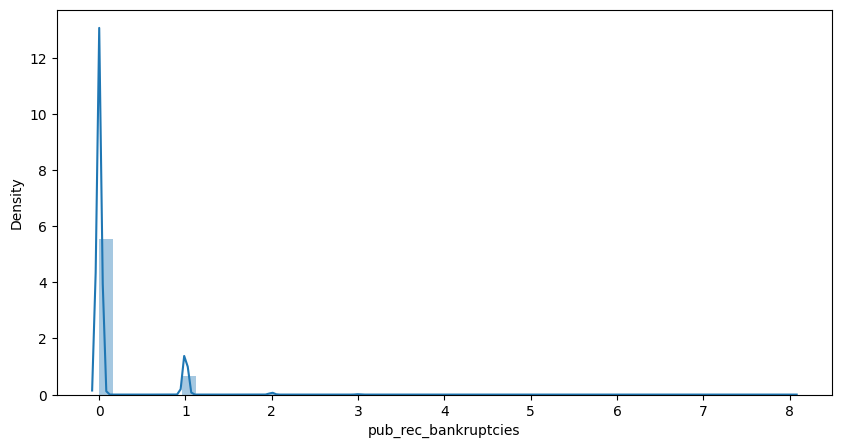

In [ ]:
for i in num_cols:
    plt.figure(figsize=(10,5))
    sns.distplot(df[i])
    plt.show()



This cell, similar to an earlier one, iterates through numerical columns and generates box plots. It aims to visualize the spread and identify outliers for each numerical feature, helping to understand data variability.

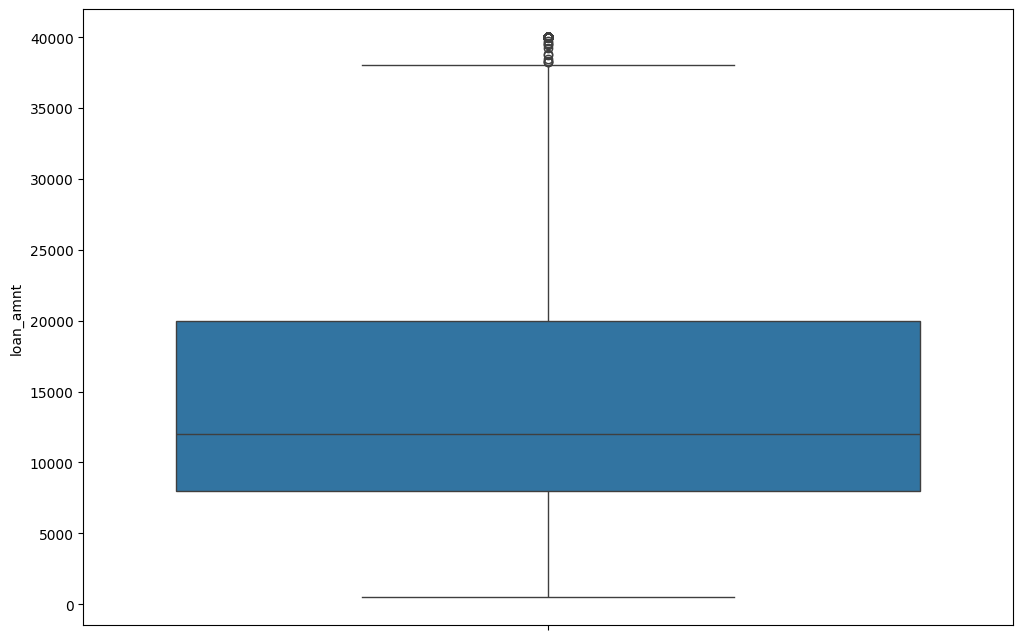

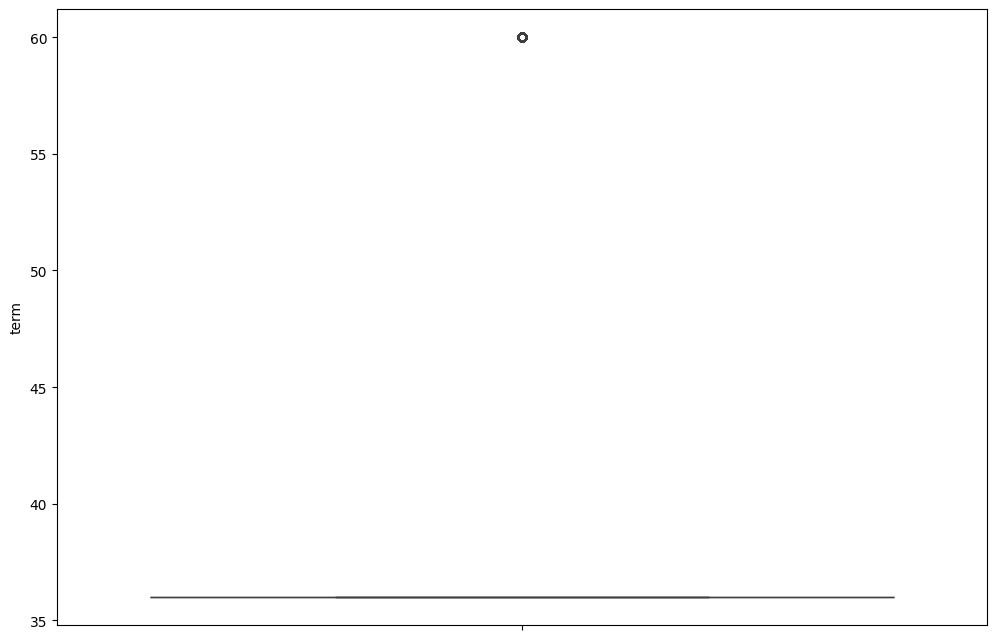

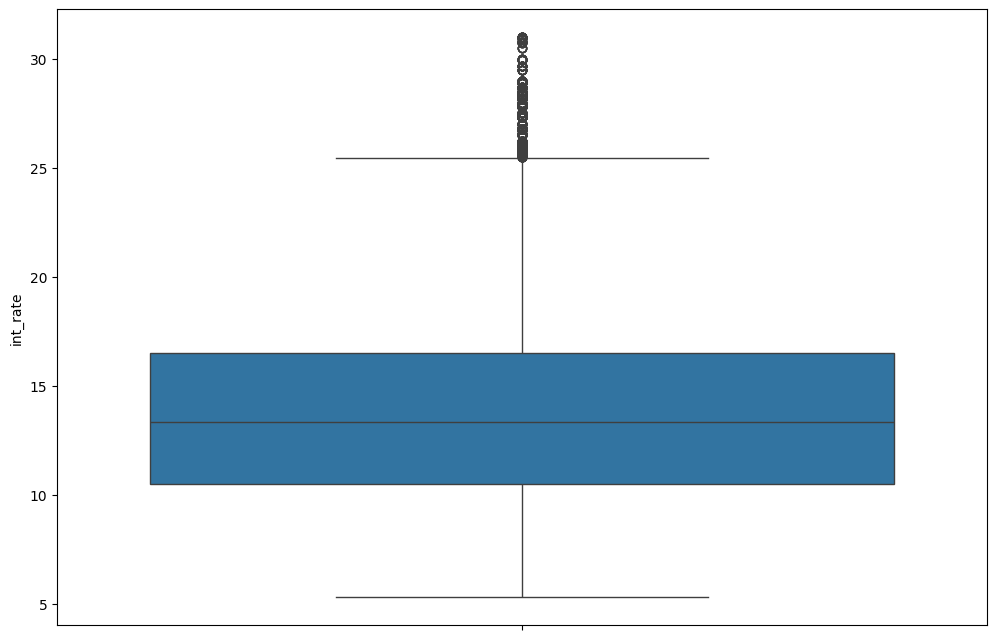

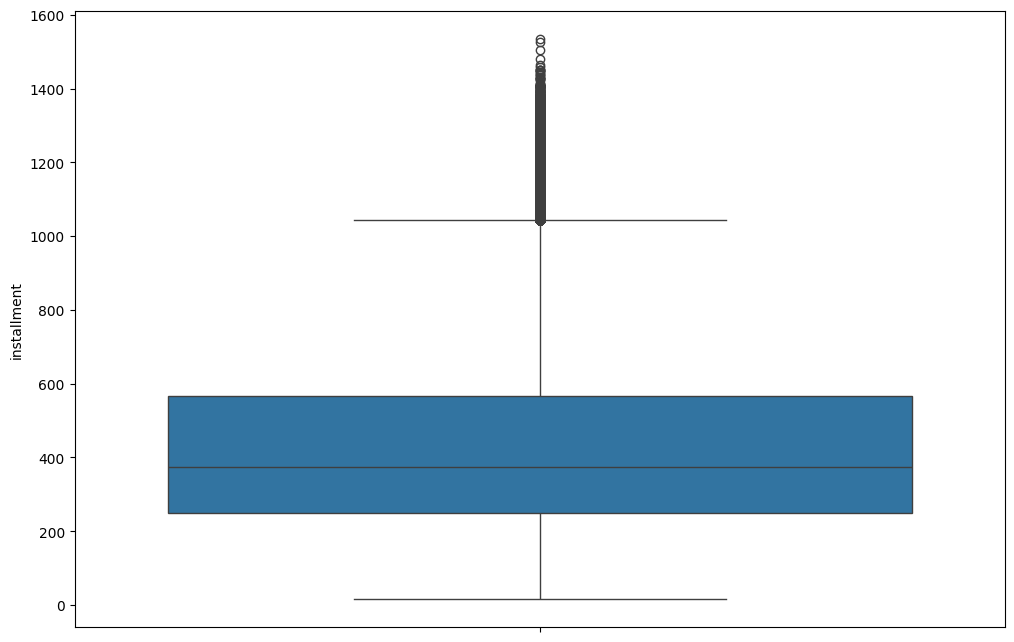

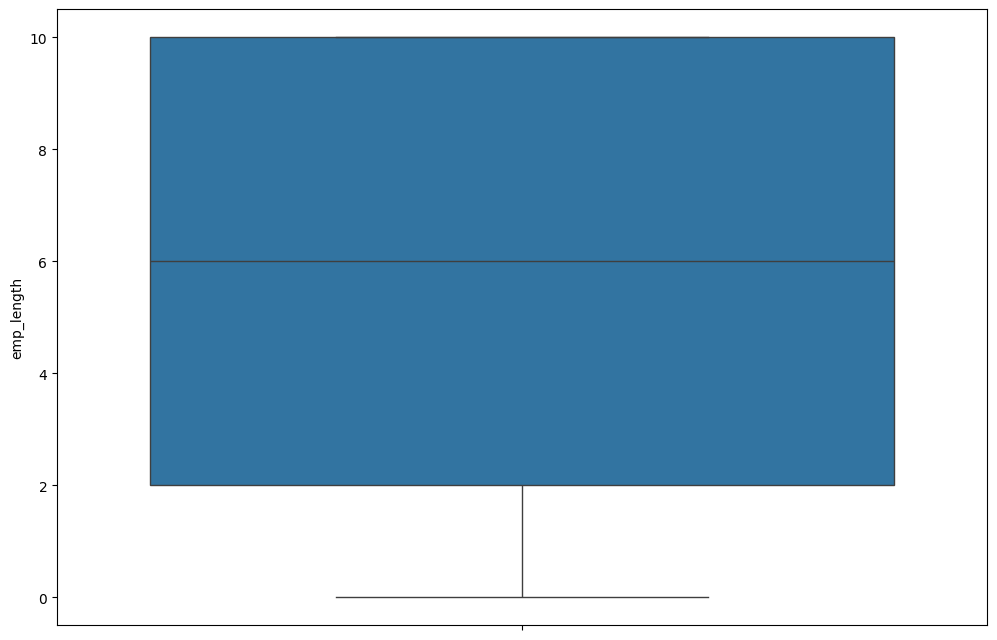

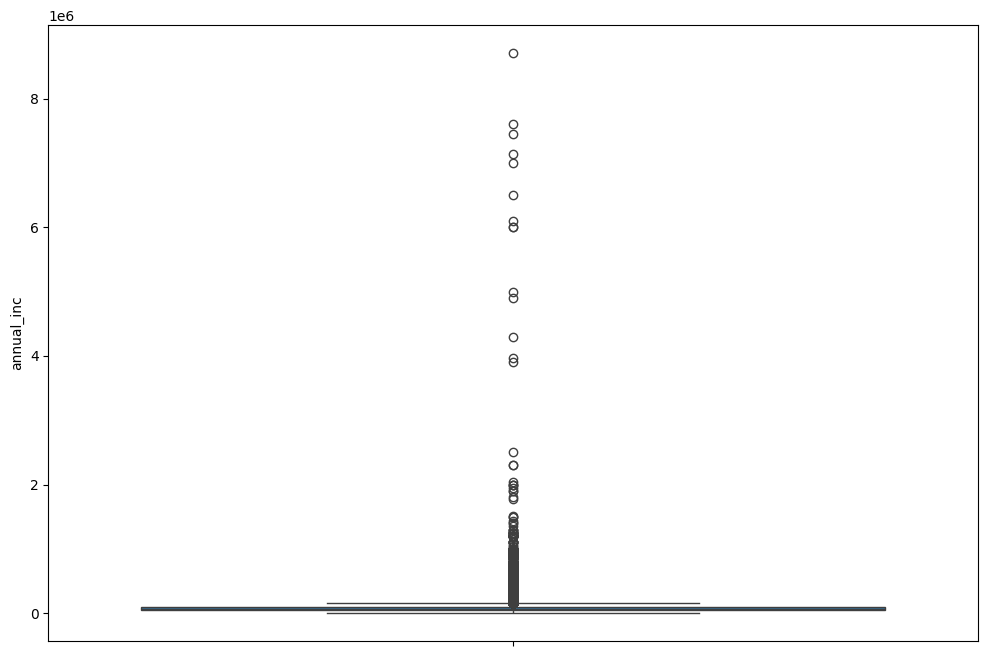

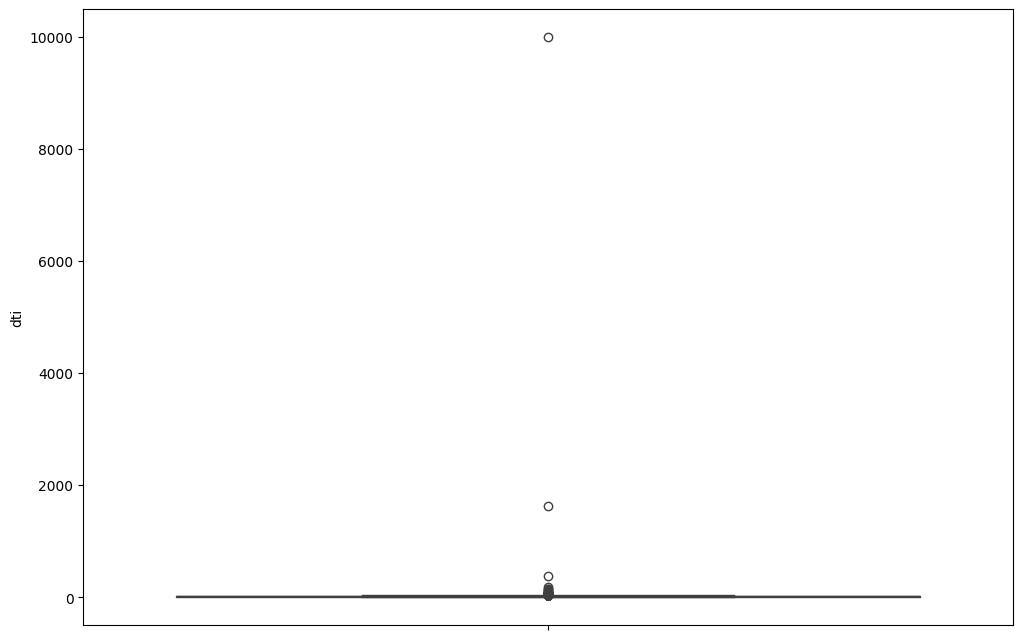

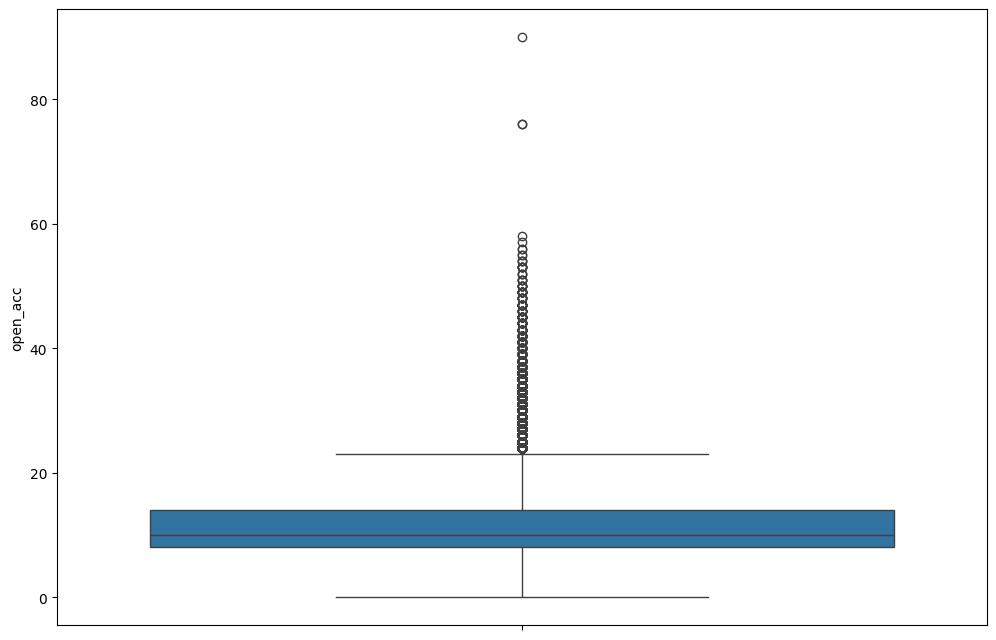

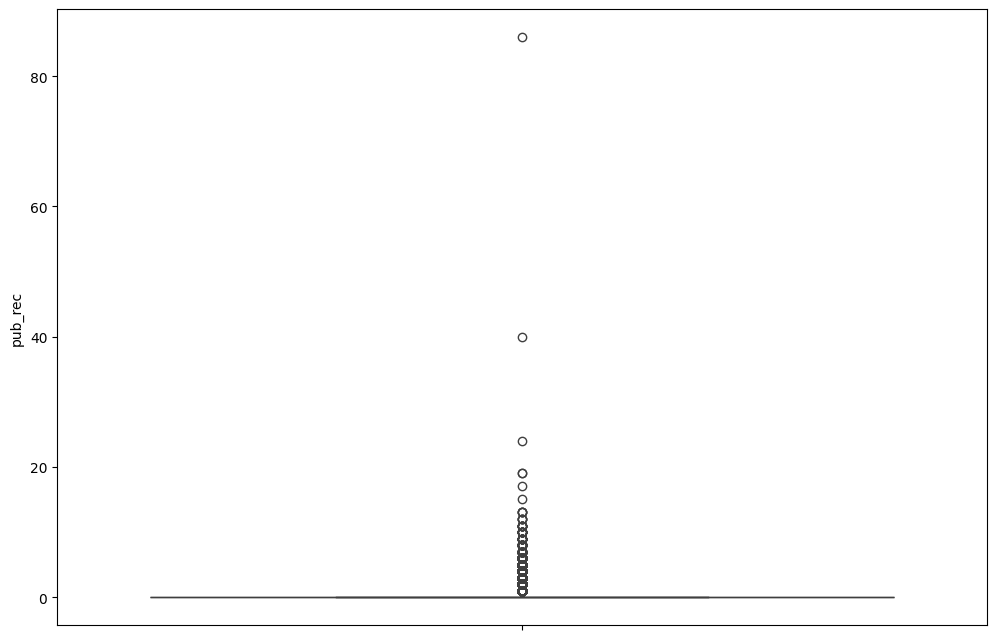

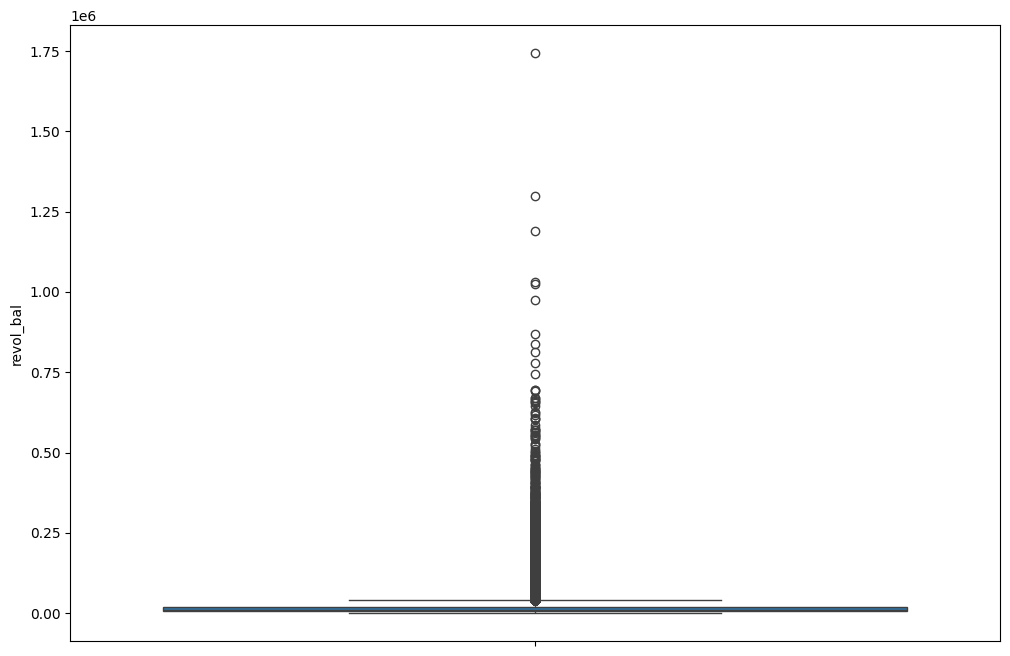

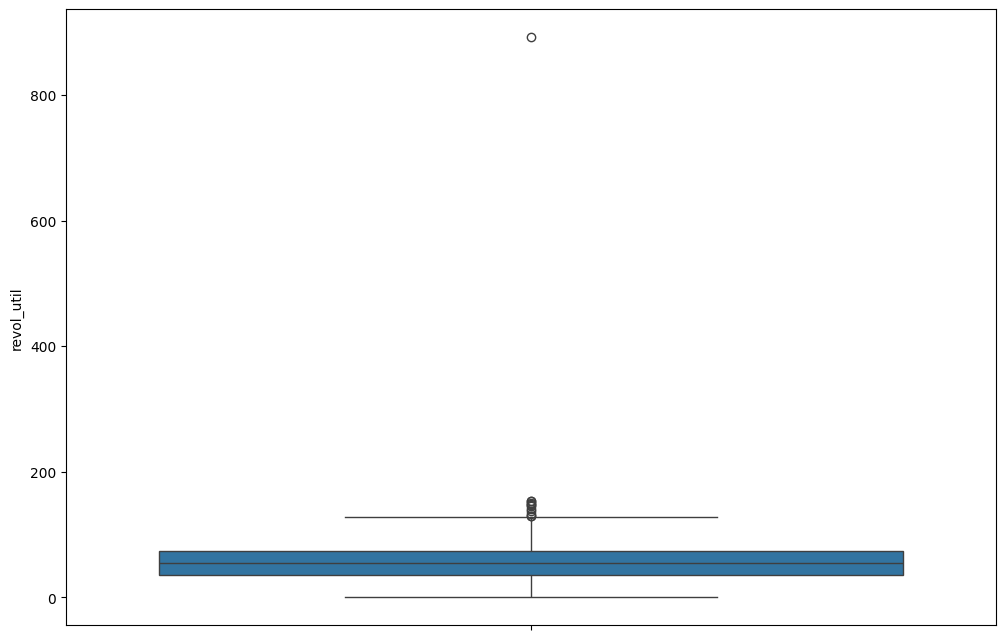

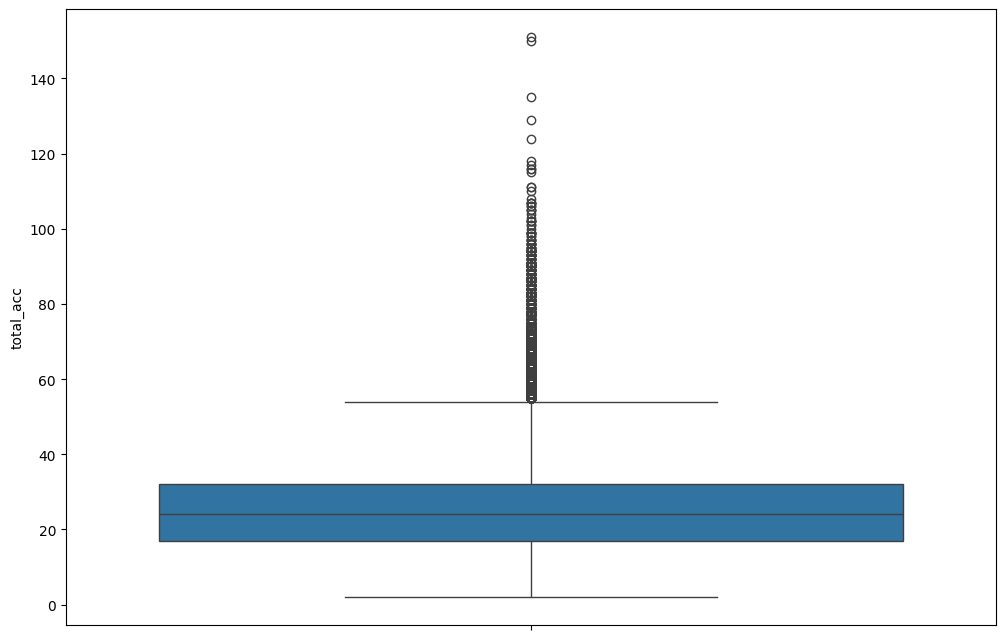

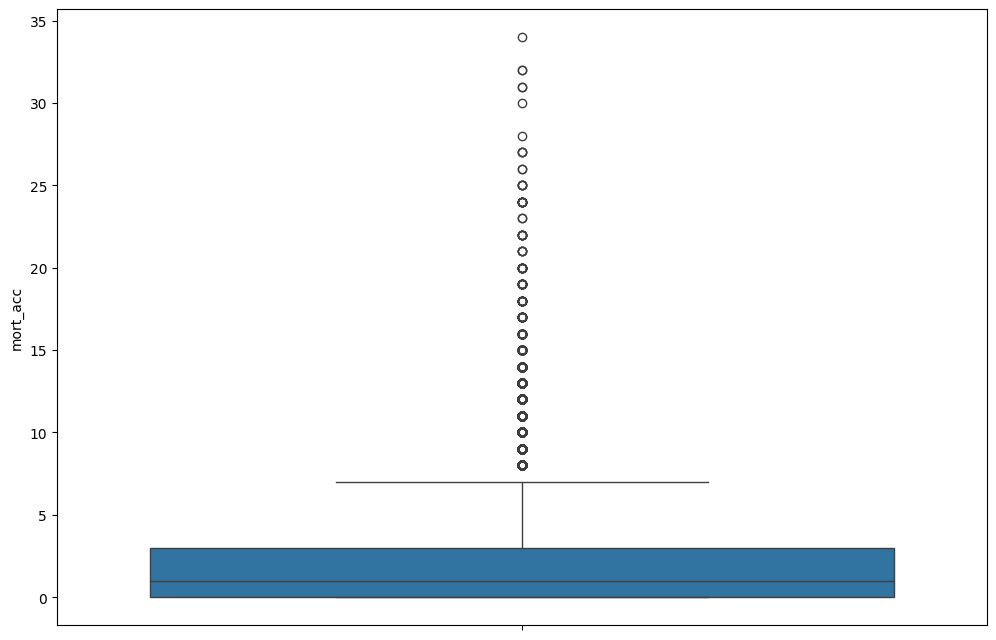

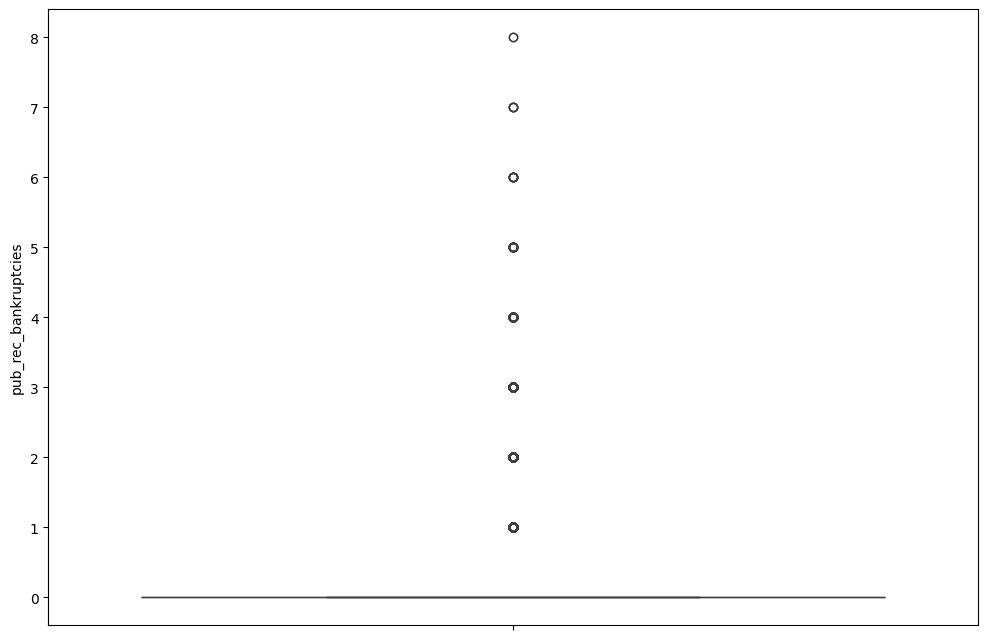

In [ ]:
for i in num_cols:
  plt.figure(figsize=(12,8))
  sns.boxplot(df[i])
  plt.show()


This cell creates bar plots to explore the relationship between the `loan_status` (target variable) and each numerical feature. By showing the average value of each numerical feature for 'Fully Paid' and 'Charged Off' loans, it helps identify potential predictors.

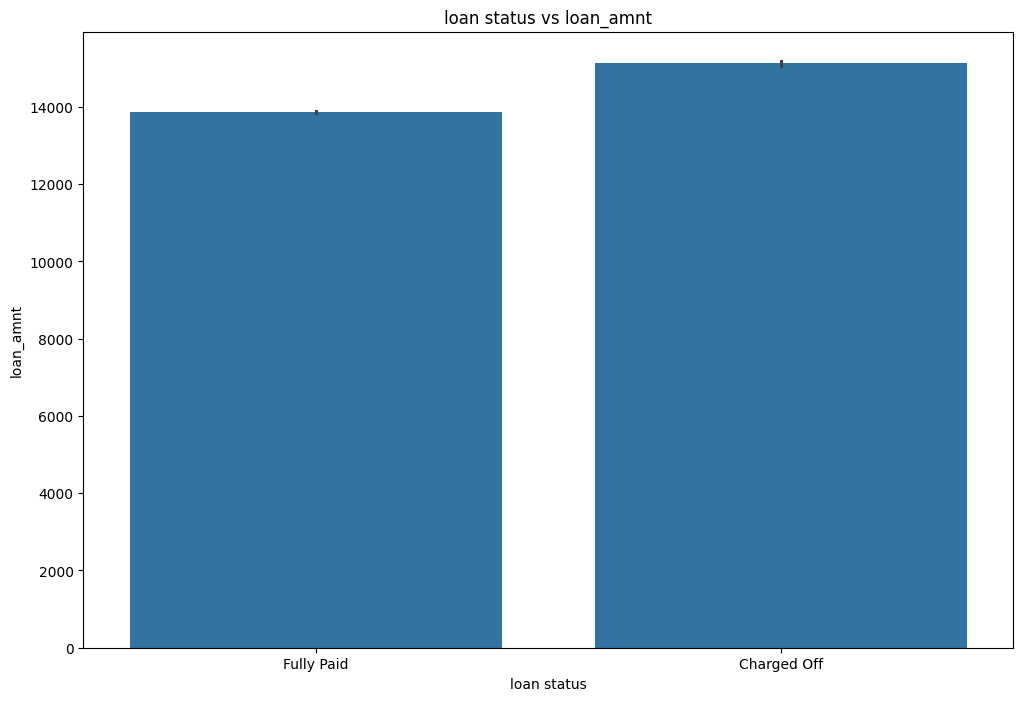

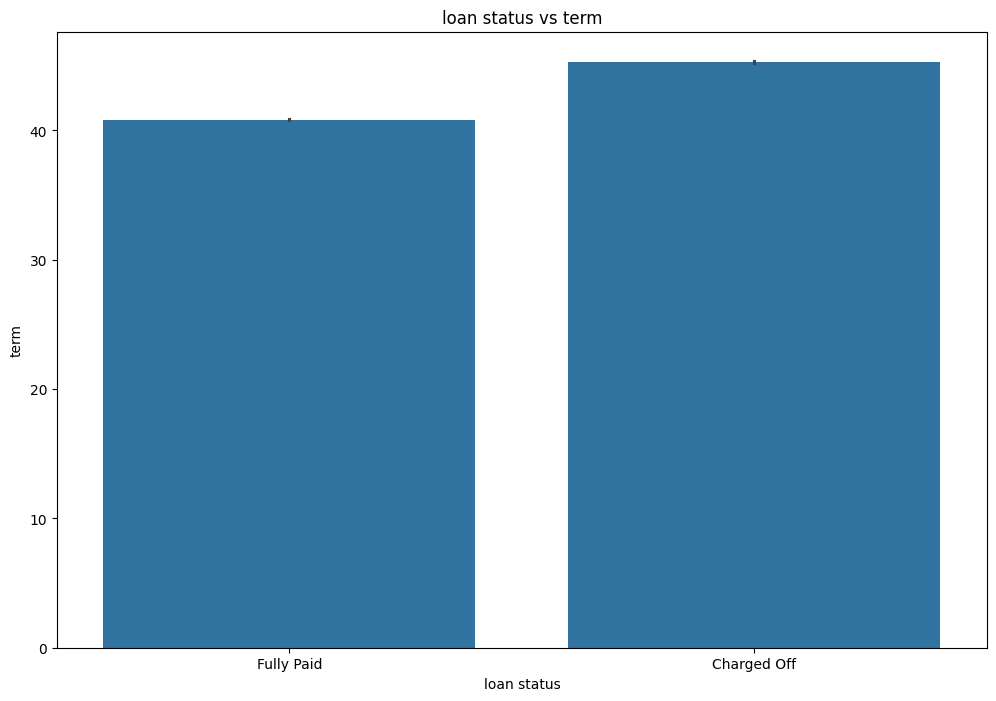

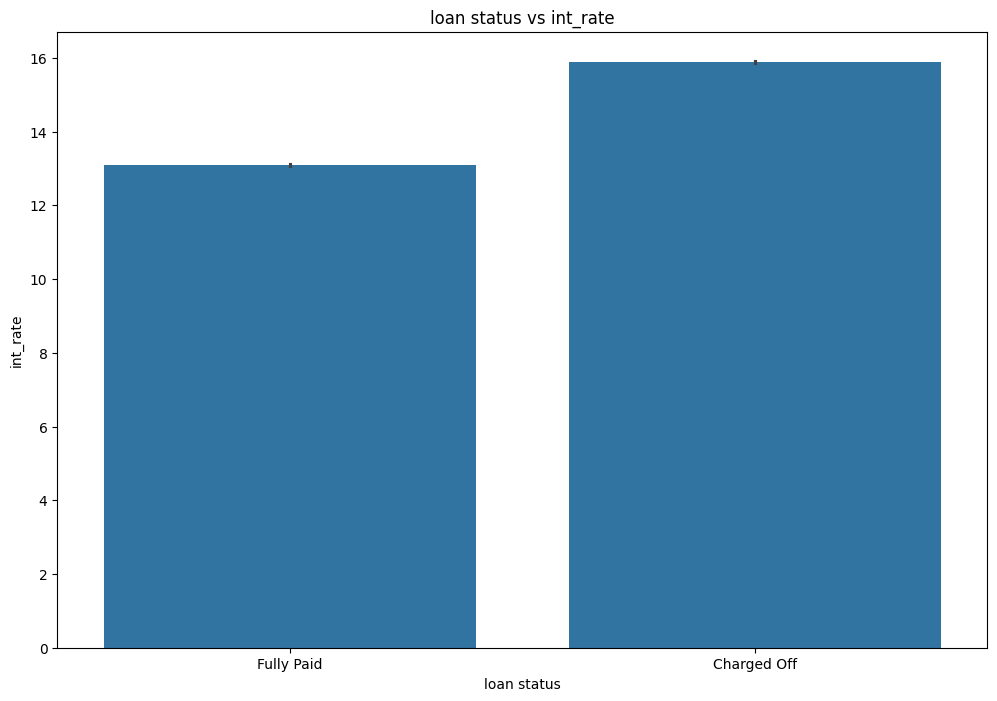

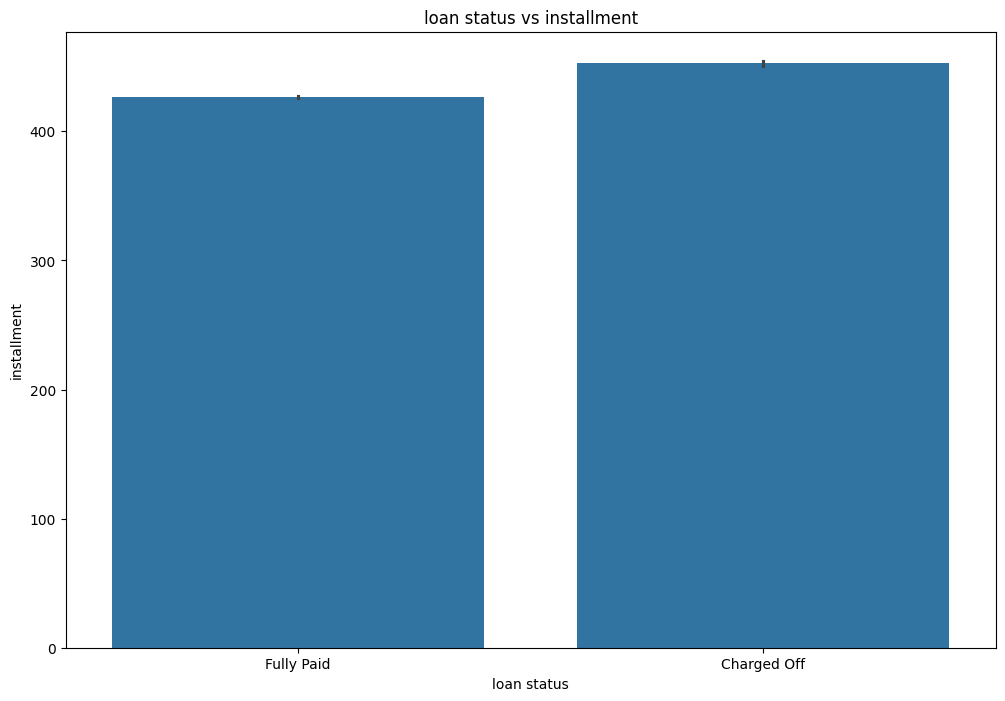

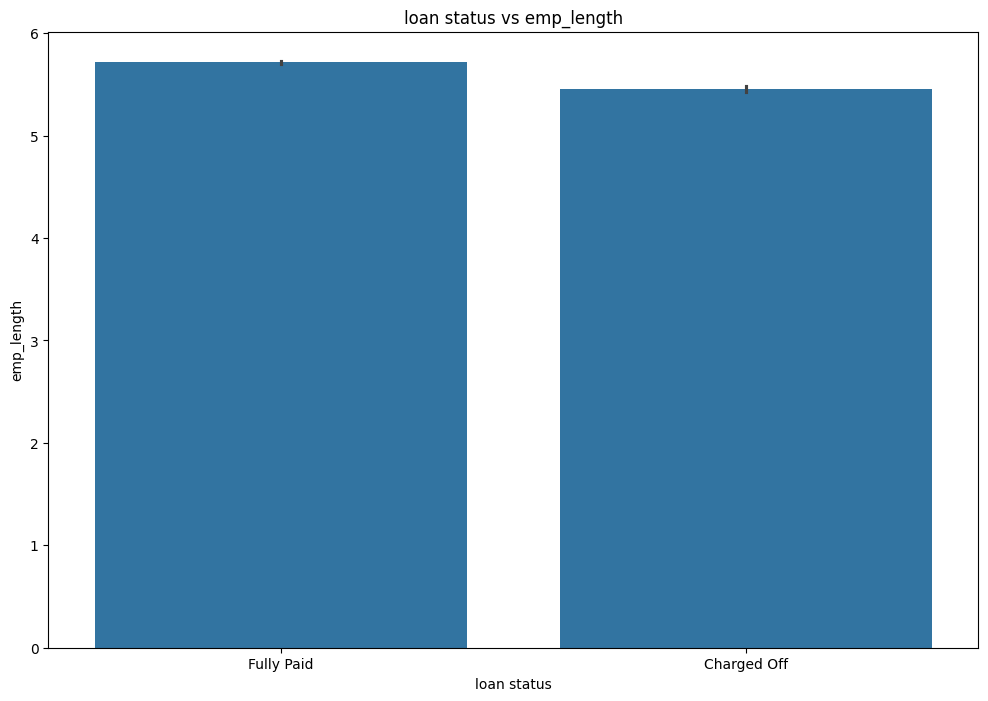

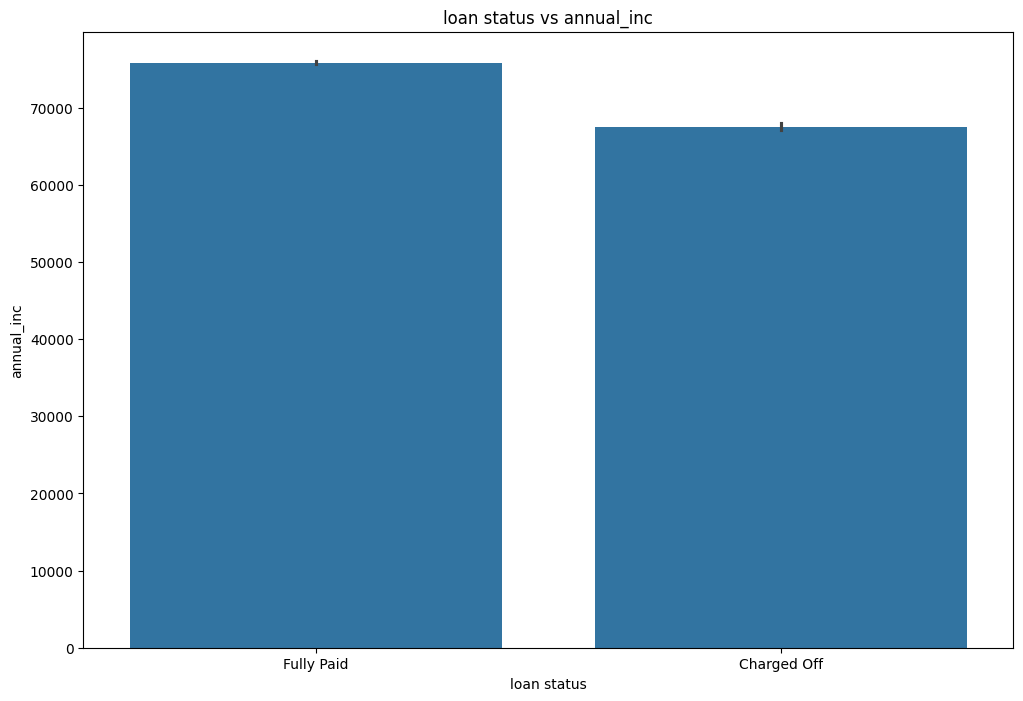

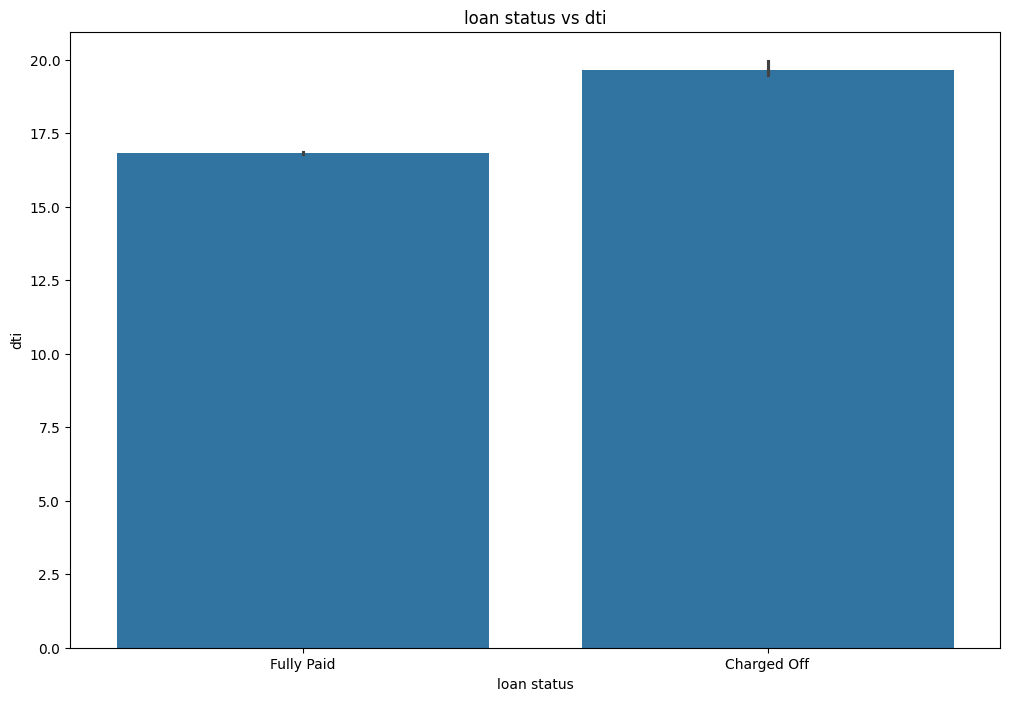

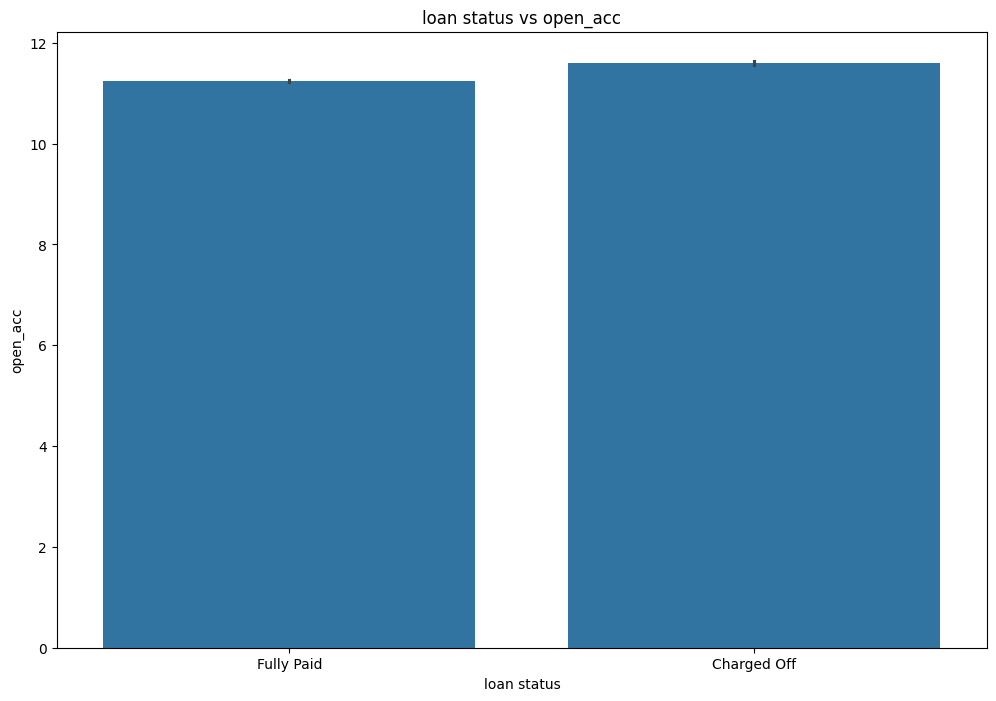

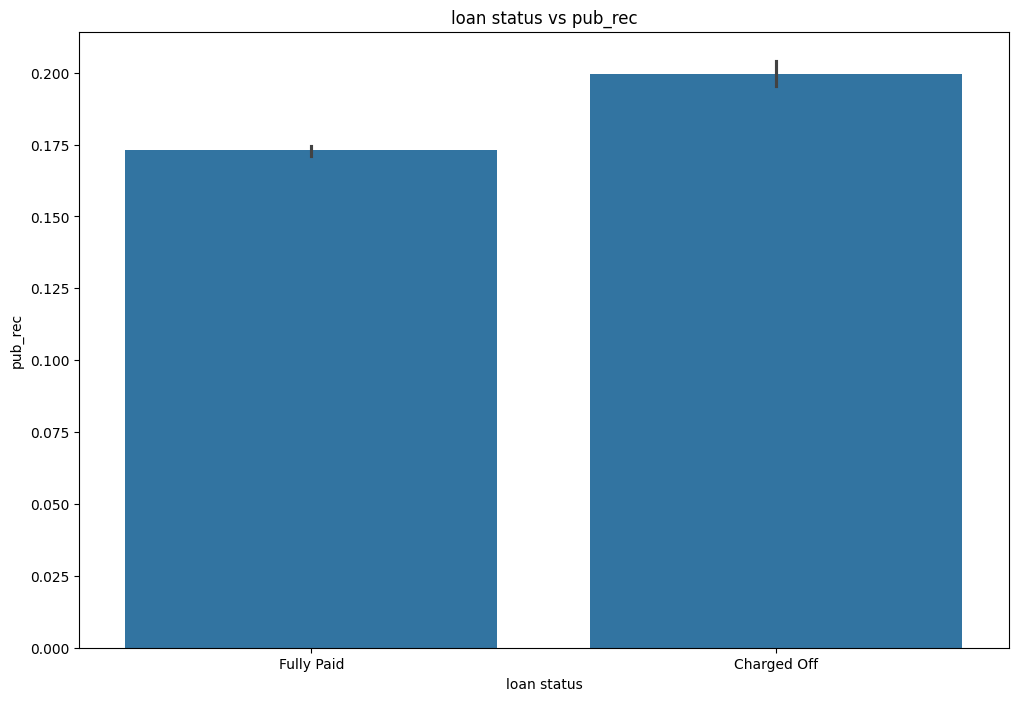

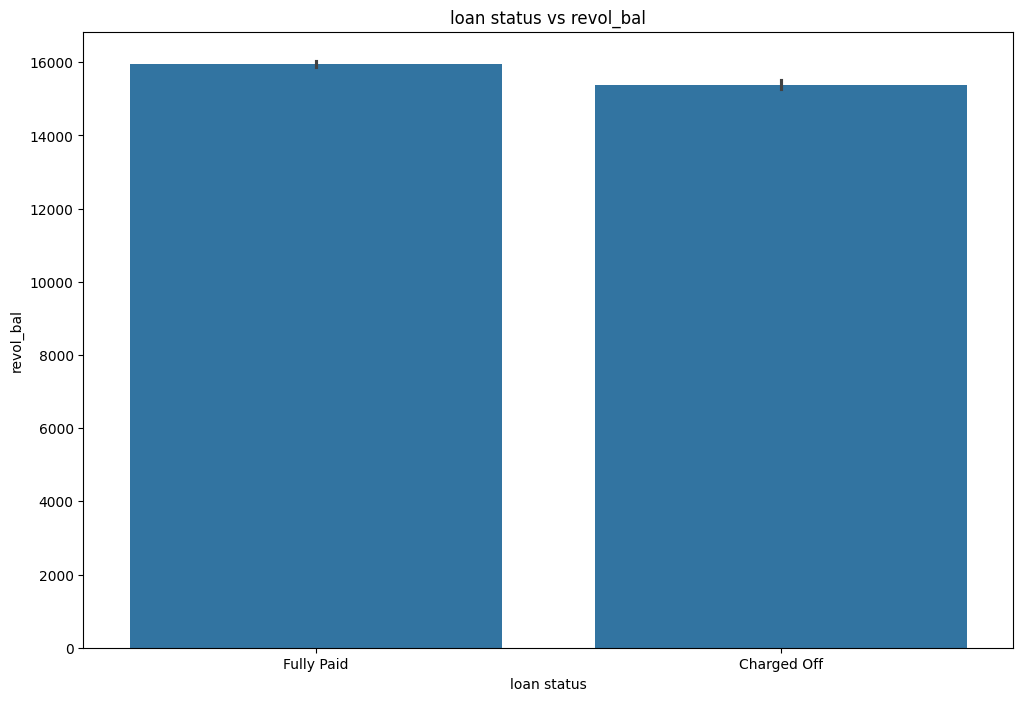

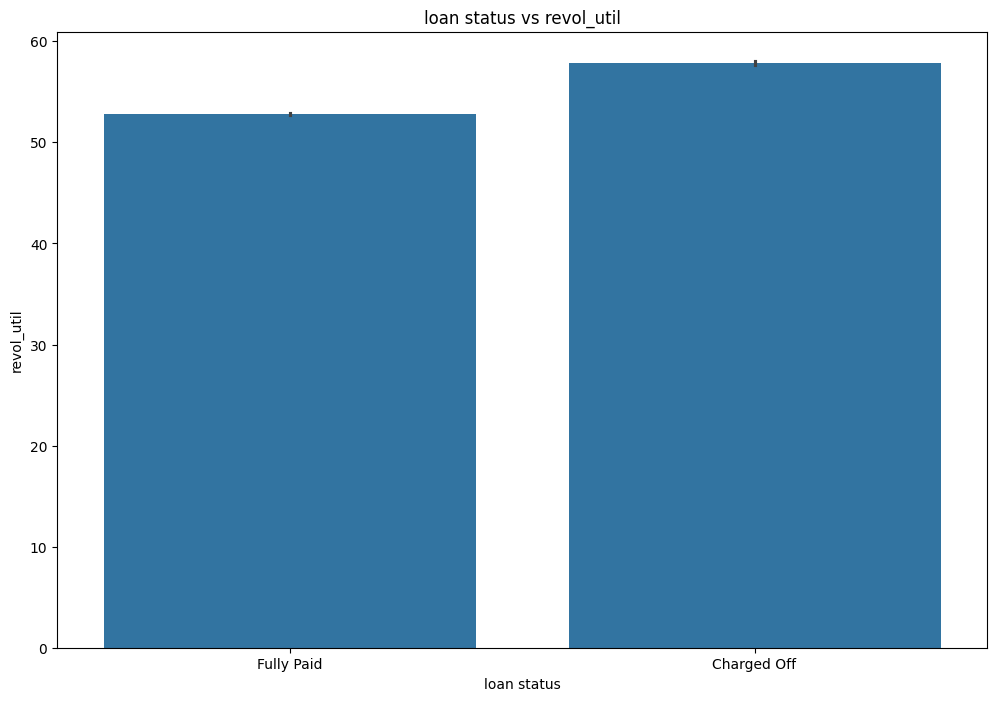

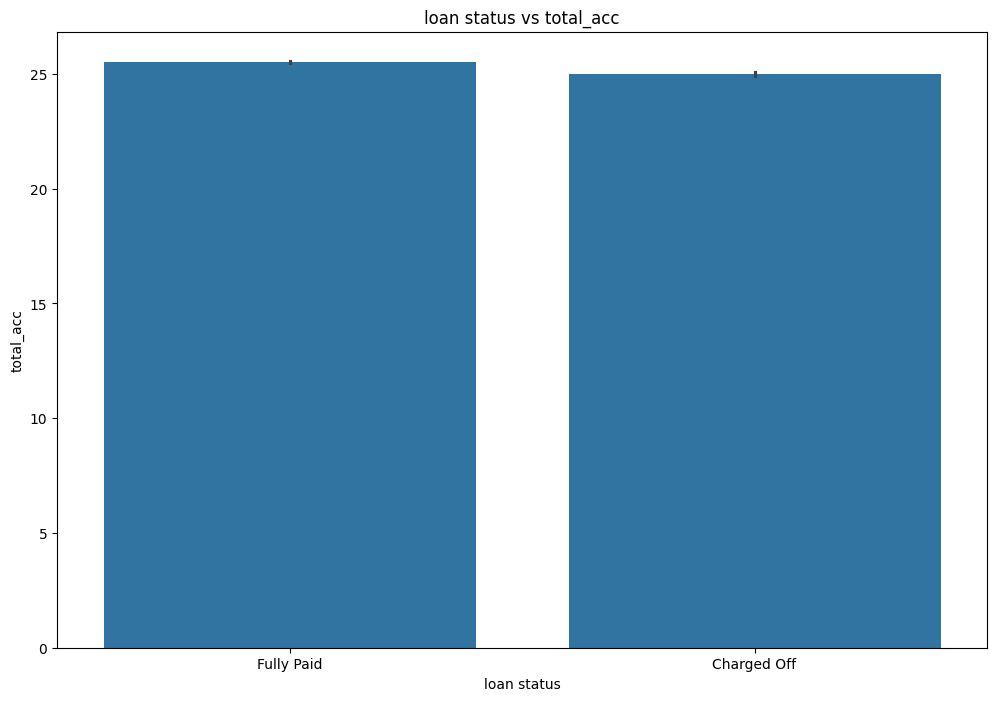

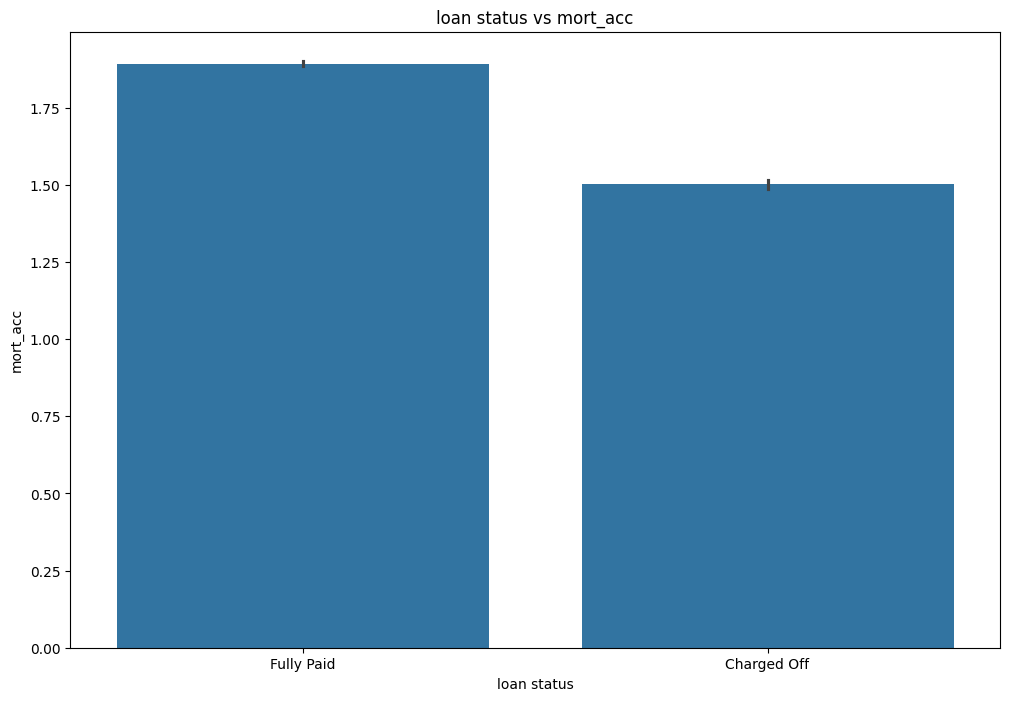

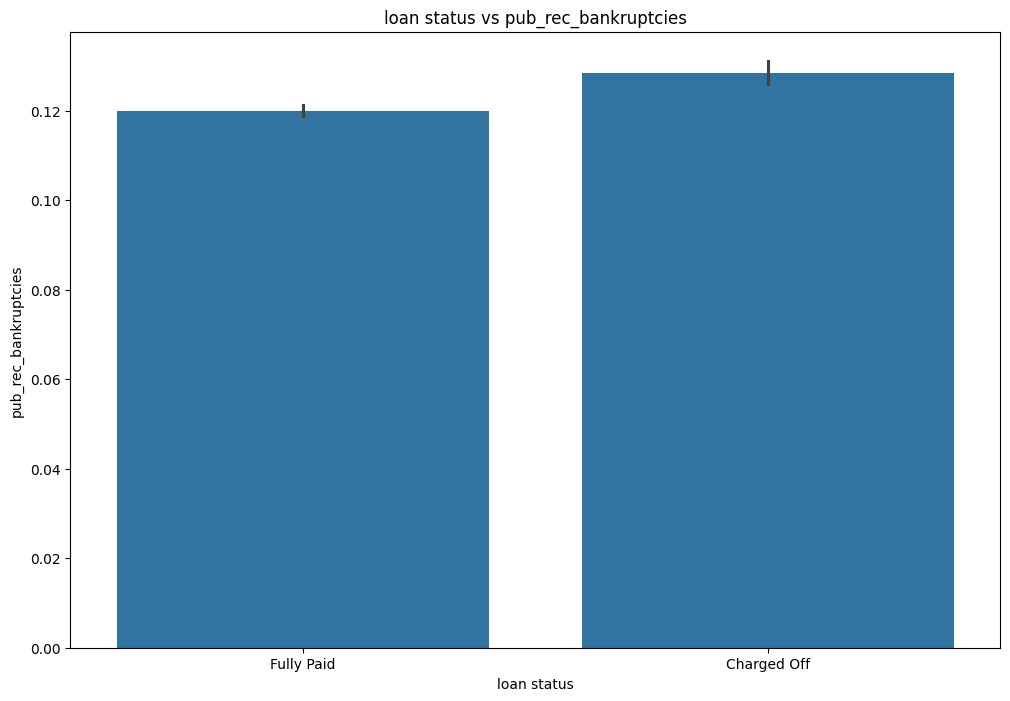

In [ ]:
for i in num_cols:
  plt.figure(figsize=(12,8))
  sns.barplot(x=df['loan_status'],y=df[i],data=df)
  plt.title(f"loan status vs {i}")
  plt.ylabel(f"{i}")
  plt.xlabel("loan status")
  plt.show()


This cell generates a pie chart to visualize the distribution of the `loan_status` column. The chart shows the proportion of 'Fully Paid' versus 'Charged Off' loans, highlighting any class imbalance in the target variable.

<Axes: ylabel='count'>

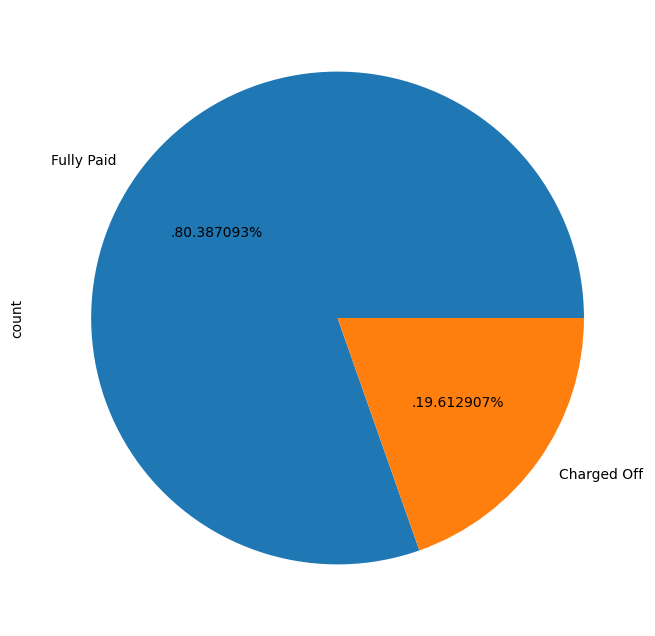

In [ ]:
plt.figure(figsize=(12,8))
df['loan_status'].value_counts().plot(kind="pie",autopct=".%2f%%")


This cell simply prints the first few rows (head) of the numerical columns in the DataFrame. This allows for a quick inspection of the numerical data's values.

In [ ]:
print(df[num_cols].head())

   loan_amnt  term  int_rate  installment  emp_length  annual_inc    dti  \
0      10000    36     11.44       329.48          10    117000.0  26.24   
1       8000    36     11.99       265.68           4     65000.0  22.05   
2      15600    36     10.49       506.97           0     43057.0  12.79   
3       7200    36      6.49       220.65           6     54000.0   2.60   
4      24375    60     17.27       609.33           9     55000.0  33.95   

   open_acc  pub_rec  revol_bal  revol_util  total_acc  mort_acc  \
0        16        0      36369        41.8         25       0.0   
1        17        0      20131        53.3         27       3.0   
2        13        0      11987        92.2         26       0.0   
3         6        0       5472        21.5         13       0.0   
4        13        0      24584        69.8         43       1.0   

   pub_rec_bankruptcies  
0                   0.0  
1                   0.0  
2                   0.0  
3                   0.0  
4   


This cell generates a correlation heatmap for all numerical columns. The heatmap visually represents the Pearson correlation coefficients between pairs of numerical features, helping to identify highly correlated variables.

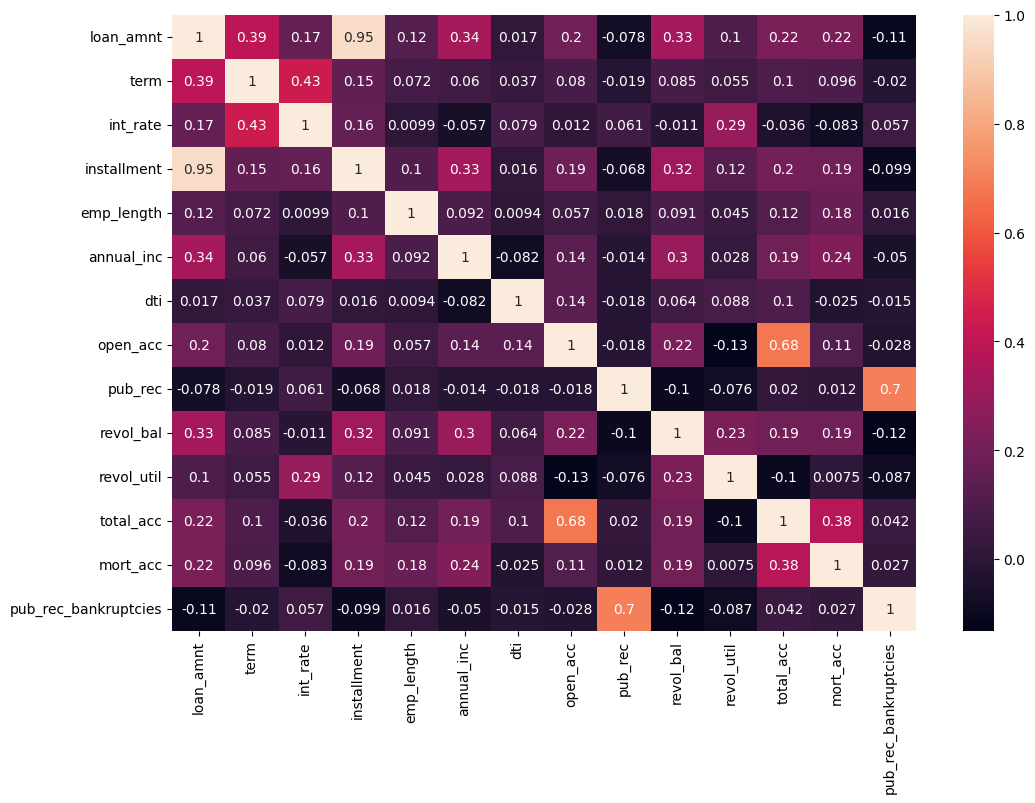

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(),annot=True)
plt.show()


This cell performs a Chi-squared test of independence between the `loan_status` and all other columns (both numerical and categorical, after creating contingency tables). It prints the p-value for each test, indicating the statistical significance of the relationship between each variable and the loan status.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table between the dependent variable and each independent variable
for col in df.columns:
   if col != 'loan_status':
        contingency_table = pd.crosstab(df[col], df['loan_status'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(col, "p-value:", p)


loan_amnt p-value: 0.0
term p-value: 0.0
int_rate p-value: 0.0
installment p-value: 0.0
grade p-value: 0.0
sub_grade p-value: 0.0
emp_length p-value: 2.8542293620802177e-109
home_ownership p-value: 0.0
annual_inc p-value: 1.0041799412989809e-48
verification_status p-value: 0.0
issue_d p-value: 0.0
purpose p-value: 6.573354783158025e-291
dti p-value: 0.0
earliest_cr_line p-value: 5.739811970338021e-108
open_acc p-value: 3.2501317050944036e-47
pub_rec p-value: 3.1977870014319198e-31
revol_bal p-value: 0.9999960266411639
revol_util p-value: 1.2904355637308822e-287
total_acc p-value: 6.100571917442791e-20
application_type p-value: 1.1418557766942247e-13
mort_acc p-value: 0.0
pub_rec_bankruptcies p-value: 4.056824231550618e-07
address p-value: 0.18511571879723165



Based on previous analysis (potentially the Chi-squared test results or domain knowledge), this cell drops the 'revol_bal' and 'address' columns from the DataFrame in-place. These columns might have been found to be not significantly correlated with the target or deemed irrelevant.

In [ ]:
df.drop(columns=['revol_bal','address'],inplace=True)


This cell updates the `num_cols` list by removing 'revol_bal' since it was dropped from the DataFrame. It then prints the updated list of numerical column names.

In [ ]:
num_cols=num_cols.drop('revol_bal')
num_cols

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length',
       'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_util', 'total_acc',
       'mort_acc', 'pub_rec_bankruptcies'],
      dtype='object')


This cell calculates and displays the skewness for all numerical columns. Skewness measures the asymmetry of the probability distribution of a real-valued random variable about its mean. High skewness often indicates the need for transformation.

In [ ]:
df[num_cols].skew().sort_values(ascending=True)

,0
emp_length,-0.143894
revol_util,-0.071778
int_rate,0.420669
loan_amnt,0.777285
total_acc,0.864328
installment,0.983598
open_acc,1.213019
term,1.234225
mort_acc,1.600132
pub_rec_bankruptcies,3.423440



This cell applies a `PowerTransformer` (Yeo-Johnson method) to a selection of highly skewed numerical columns (`dti`, `annual_inc`, `pub_rec`, `pub_rec_bankruptcies`, `mort_acc`, `term`). The purpose is to reduce skewness and make the distributions more Gaussian-like, which can improve model performance. It then re-calculates and displays the skewness for these transformed columns.

In [ ]:
cols_new=['dti','annual_inc','pub_rec','pub_rec_bankruptcies','mort_acc','term']

df_copy=df
from sklearn.preprocessing import PowerTransformer
scaler = PowerTransformer(method = 'yeo-johnson', standardize=True)
df_copy[cols_new] = scaler.fit_transform(df_copy[cols_new].values)

df_copy[cols_new].skew().sort_values(ascending=True)

,0
annual_inc,-0.025971
term,0.000000
mort_acc,0.100388
dti,1.187354
pub_rec,2.006863
pub_rec_bankruptcies,2.427999



This cell displays the first 3 rows of the DataFrame (`df_copy`) after applying the `PowerTransformer` to a subset of numerical columns. This allows for a quick check of the transformed values.

In [ ]:

df_copy.head(3)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,earliest_cr_line,open_acc,pub_rec,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies
0,10000,-2.714495e-14,11.44,329.48,B,B4,10,RENT,1.145691,Not Verified,1/15/2023,Fully Paid,vacation,1.034527,6/1/1990,16,-0.413212,41.8,25,INDIVIDUAL,-1.123675,-0.358832
1,8000,-2.714495e-14,11.99,265.68,B,B5,4,MORTGAGE,0.044891,Not Verified,1/15/2023,Fully Paid,debt_consolidation,0.628529,7/4/2023,17,-0.413212,53.3,27,INDIVIDUAL,0.899596,-0.358832
2,15600,-2.714495e-14,10.49,506.97,B,B3,0,RENT,-0.750641,Source Verified,1/15/2023,Fully Paid,credit_card,-0.436629,8/7/2023,13,-0.413212,92.2,26,INDIVIDUAL,-1.123675,-0.358832



This cell recalculates and displays the skewness for all numerical columns in `df_copy` after the Power Transformation. This helps to confirm the effectiveness of the transformation in reducing skewness.

In [ ]:
df_copy[num_cols].skew().sort_values(ascending=True)

,0
emp_length,-0.143894
revol_util,-0.071778
annual_inc,-0.025971
term,0.000000
mort_acc,0.100388
int_rate,0.420669
loan_amnt,0.777285
total_acc,0.864328
installment,0.983598
dti,1.187354



This cell attempts to generate box plots for all columns in the `df_copy` DataFrame.

<Axes: >

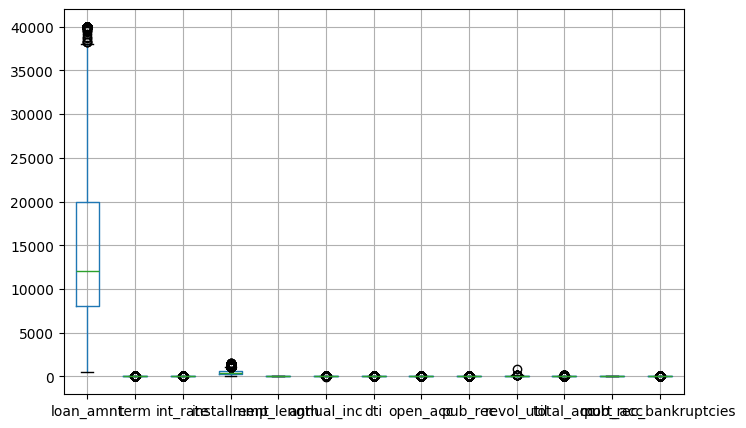

In [ ]:
df_copy.boxplot()

### Cell Description
This cell applies `MinMaxScaler` to several numerical columns (`loan_amnt`, `int_rate`, `installment`, `open_acc`, `revol_util`, `total_acc`). Min-Max scaling transforms features to a common range (typically 0 to 1), which is important for algorithms sensitive to feature scales.

In [ ]:
scalar = MinMaxScaler()
df_copy[['loan_amnt']] = scalar.fit_transform(df_copy[['loan_amnt']])
df_copy[['int_rate']] = scalar.fit_transform(df_copy[['int_rate']])
df_copy[['installment']] = scalar.fit_transform(df_copy[['installment']])
df_copy[['open_acc']] = scalar.fit_transform(df_copy[['open_acc']])
df_copy[['revol_util']] = scalar.fit_transform(df_copy[['revol_util']])
df_copy[['total_acc']] = scalar.fit_transform(df_copy[['total_acc']])


This cell displays the first 3 rows of the DataFrame (`df_copy`) after applying Min-Max scaling to a subset of numerical columns, allowing verification of the scaling effect.

In [ ]:
df_copy.head(3)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,earliest_cr_line,open_acc,pub_rec,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies
0,0.240506,-2.714495e-14,0.238411,0.206493,B,B4,10,RENT,1.145691,Not Verified,1/15/2023,Fully Paid,vacation,1.034527,6/1/1990,0.177778,-0.413212,0.046845,0.154362,INDIVIDUAL,-1.123675,-0.358832
1,0.189873,-2.714495e-14,0.259836,0.164456,B,B5,4,MORTGAGE,0.044891,Not Verified,1/15/2023,Fully Paid,debt_consolidation,0.628529,7/4/2023,0.188889,-0.413212,0.059733,0.167785,INDIVIDUAL,0.899596,-0.358832
2,0.382278,-2.714495e-14,0.201402,0.323437,B,B3,0,RENT,-0.750641,Source Verified,1/15/2023,Fully Paid,credit_card,-0.436629,8/7/2023,0.144444,-0.413212,0.103328,0.161074,INDIVIDUAL,-1.123675,-0.358832



This cell removes the 'address' column from the `cate_cols` list (as 'address' was previously dropped from the DataFrame) and then displays the first 3 rows of the remaining categorical columns.

In [ ]:
cate_cols = cate_cols.drop('address')
df_cols=df_copy[cate_cols]
df_cols.head(3)

,grade,sub_grade,home_ownership,verification_status,issue_d,loan_status,purpose,earliest_cr_line,application_type
0,B,B4,RENT,Not Verified,1/15/2023,Fully Paid,vacation,6/1/1990,INDIVIDUAL
1,B,B5,MORTGAGE,Not Verified,1/15/2023,Fully Paid,debt_consolidation,7/4/2023,INDIVIDUAL
2,B,B3,RENT,Source Verified,1/15/2023,Fully Paid,credit_card,8/7/2023,INDIVIDUAL



This cell iterates through the remaining categorical columns and prints the value counts for each one. This helps in understanding the distribution of categories within each feature and identifying columns with many unique values.

In [ ]:
for i in df_cols:
    print(df_cols[i].value_counts())

grade
B    116018
C    105987
A     64187
D     63524
E     31488
F     11772
G      3054
Name: count, dtype: int64
sub_grade
B3    26655
B4    25601
C1    23662
C2    22580
B2    22495
B5    22085
C3    21221
C4    20280
B1    19182
A5    18526
C5    18244
D1    15993
A4    15789
D2    13951
D3    12223
D4    11657
A3    10576
A1     9729
D5     9700
A2     9567
E1     7917
E2     7431
E3     6207
E4     5361
E5     4572
F1     3536
F2     2766
F3     2286
F4     1787
F5     1397
G1     1058
G2      754
G3      552
G4      374
G5      316
Name: count, dtype: int64
home_ownership
MORTGAGE    198348
RENT        159790
OWN          37746
OTHER          112
NONE            31
ANY              3
Name: count, dtype: int64
verification_status
Verified           139563
Source Verified    131385
Not Verified       125082
Name: count, dtype: int64
issue_d
10/14/2023    14846
7/14/2023     12609
1/15/2023     11705
12/13/2023    10618
11/13/2023    10496
7/15/2023     10270
10/13/2023    10047
1


This cell removes the 'sub_grade' column from the `cate_cols` list. This indicates that 'sub_grade' might either be dropped later or handled differently (e.g., as part of 'grade' or directly encoded).

In [ ]:
cate_cols=cate_cols.drop('sub_grade')
cate_cols

Index(['grade', 'home_ownership', 'verification_status', 'issue_d',
       'loan_status', 'purpose', 'earliest_cr_line', 'application_type'],
      dtype='object')


This cell performs one-hot encoding on the identified categorical columns using `pd.get_dummies`. The `drop_first=True` argument avoids multicollinearity. The resulting `df_dummy` DataFrame contains numerical representations of the original categorical features, ready for machine learning models.

In [ ]:
df_dummy=pd.get_dummies(data=df_copy,columns=cate_cols,drop_first=True)
df_dummy.head(3)

,loan_amnt,term,int_rate,installment,sub_grade,emp_length,annual_inc,dti,open_acc,pub_rec,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,issue_d_1/11/2023,issue_d_1/12/2023,issue_d_1/13/2023,issue_d_1/14/2023,issue_d_1/15/2023,issue_d_1/16/2023,issue_d_1/8/2023,issue_d_1/9/2023,issue_d_10/10/2023,issue_d_10/11/2023,issue_d_10/12/2023,issue_d_10/13/2023,issue_d_10/14/2023,issue_d_10/15/2023,issue_d_10/16/2023,issue_d_10/7/2023,issue_d_10/8/2023,issue_d_10/9/2023,issue_d_11/10/2023,issue_d_11/11/2023,issue_d_11/12/2023,issue_d_11/13/2023,issue_d_11/14/2023,issue_d_11/15/2023,issue_d_11/16/2023,issue_d_11/7/2023,issue_d_11/8/2023,issue_d_11/9/2023,issue_d_12/10/2023,issue_d_12/11/2023,issue_d_12/12/2023,issue_d_12/13/2023,issue_d_12/14/2023,issue_d_12/15/2023,issue_d_12/16/2023,issue_d_12/7/2023,issue_d_12/8/2023,issue_d_12/9/2023,issue_d_2/10/2023,issue_d_2/11/2023,issue_d_2/12/2023,issue_d_2/13/2023,issue_d_2/14/2023,issue_d_2/15/2023,issue_d_2/16/2023,issue_d_2/8/2023,issue_d_2/9/2023,issue_d_3/10/2023,issue_d_3/11/2023,issue_d_3/12/2023,issue_d_3/13/2023,issue_d_3/14/2023,issue_d_3/15/2023,issue_d_3/16/2023,issue_d_3/8/2023,issue_d_3/9/2023,issue_d_4/10/2023,issue_d_4/11/2023,issue_d_4/12/2023,issue_d_4/13/2023,issue_d_4/14/2023,issue_d_4/15/2023,issue_d_4/16/2023,issue_d_4/8/2023,issue_d_4/9/2023,issue_d_5/10/2023,issue_d_5/11/2023,issue_d_5/12/2023,issue_d_5/13/2023,issue_d_5/14/2023,issue_d_5/15/2023,issue_d_5/16/2023,issue_d_5/8/2023,issue_d_5/9/2023,issue_d_6/10/2023,issue_d_6/11/2023,issue_d_6/12/2023,issue_d_6/13/2023,issue_d_6/14/2023,issue_d_6/15/2023,issue_d_6/16/2023,issue_d_6/7/2023,issue_d_6/8/2023,issue_d_6/9/2023,issue_d_7/10/2023,issue_d_7/11/2023,issue_d_7/12/2023,issue_d_7/13/2023,issue_d_7/14/2023,issue_d_7/15/2023,issue_d_7/16/2023,issue_d_7/7/2023,issue_d_7/8/2023,issue_d_7/9/2023,issue_d_8/10/2023,issue_d_8/11/2023,issue_d_8/12/2023,issue_d_8/13/2023,issue_d_8/14/2023,issue_d_8/15/2023,issue_d_8/16/2023,issue_d_8/7/2023,issue_d_8/8/2023,issue_d_8/9/2023,issue_d_9/10/2023,issue_d_9/11/2023,issue_d_9/12/2023,issue_d_9/13/2023,issue_d_9/14/2023,issue_d_9/15/2023,issue_d_9/16/2023,issue_d_9/7/2023,issue_d_9/8/2023,issue_d_9/9/2023,loan_status_Fully Paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,earliest_cr_line_1/1/1948,earliest_cr_line_1/1/1953,earliest_cr_line_1/1/1954,earliest_cr_line_1/1/1955,earliest_cr_line_1/1/1956,earliest_cr_line_1/1/1957,earliest_cr_line_1/1/1958,earliest_cr_line_1/1/1959,earliest_cr_line_1/1/1960,earliest_cr_line_1/1/1961,earliest_cr_line_1/1/1962,earliest_cr_line_1/1/1963,earliest_cr_line_1/1/1964,earliest_cr_line_1/1/1965,earliest_cr_line_1/1/1966,earliest_cr_line_1/1/1967,earliest_cr_line_1/1/1968,earliest_cr_line_1/1/1969,earliest_cr_line_1/1/1970,earliest_cr_line_1/1/1971,earliest_cr_line_1/1/1972,earliest_cr_line_1/1/1973,earliest_cr_line_1/1/1974,earliest_cr_line_1/1/1975,earliest_cr_line_1/1/1976,earliest_cr_line_1/1/1977,earliest_cr_line_1/1/1978,earliest_cr_line_1/1/1979,earliest_cr_line_1/1/1980,earliest_cr_line_1/1/1981,earliest_cr_line_1/1/1982,earliest_cr_line_1/1/1983,earliest_cr_line_1/1/1984,earliest_cr_line_1/1/1985,earliest_cr_line_1/1/1986,earliest_cr_line_1/1/1987,earliest_cr_line_1/1/1988,earliest_cr_line_1/1/1989,earliest_cr_line_1/1/1990,earliest_cr_line_1/1/1991,earliest_cr_line_1/1/1992,earliest_cr_line_1/1/1993,earliest_cr_line_1/1/1994,earliest_cr_line_1/1/1995,earliest_cr_line_1/1/1996,earliest_cr_line_1/1/1997,earliest_cr_line_1/1/1998,earliest_cr_line_1/1/1999,earliest_cr_line_1/1/2000,earliest_cr_line_1/1/2023,earliest_cr_l


This cell prepares the data for model training:
1. It drops the 'sub_grade' column from `df_dummy` if it still exists (it was removed from `cate_cols` earlier, but this ensures it's not in the final DataFrame).
2. It imputes missing values in `revol_util`, `mort_acc`, and `pub_rec_bankruptcies` using their respective means.
3. It separates features (`X`) from the target variable (`y`, which is 'loan_status_Fully Paid').
4. Finally, it splits the dataset into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) with a 70/30 split and `random_state=101` for reproducibility.

In [ ]:
if 'sub_grade' in df_dummy.columns:
    df_dummy = df_dummy.drop('sub_grade', axis=1)

# Impute missing values in numerical columns before splitting
df_dummy['revol_util'] = df_dummy['revol_util'].fillna(df_dummy['revol_util'].mean())
df_dummy['mort_acc'] = df_dummy['mort_acc'].fillna(df_dummy['mort_acc'].mean())
df_dummy['pub_rec_bankruptcies'] = df_dummy['pub_rec_bankruptcies'].fillna(df_dummy['pub_rec_bankruptcies'].mean())

X = df_dummy.drop('loan_status_Fully Paid',axis=1)
y = df_dummy['loan_status_Fully Paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)


This cell initializes a Logistic Regression model using `solver='liblinear'` and then trains (`fits`) the model on the `X_train` and `y_train` datasets. This is the initial attempt to build a predictive model.

In [ ]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(solver='liblinear')
log_model.fit(X_train,y_train)

LogisticRegression(solver='liblinear')


This cell uses the trained Logistic Regression model to make predictions on the `X_test` data. It then prints a `classification_report`, which includes precision, recall, f1-score, and support for each class ('Fully Paid' and 'Charged Off'), as well as overall accuracy.

In [ ]:
predictions = log_model.predict(X_test)
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

       False       0.54      0.08      0.14     23260
        True       0.81      0.98      0.89     95549

    accuracy                           0.81    118809
   macro avg       0.68      0.53      0.51    118809
weighted avg       0.76      0.81      0.74    118809




This cell reiterates the steps for imputing missing values in `revol_util`, `mort_acc`, and `pub_rec_bankruptcies` and re-defines the feature matrix `X` and target vector `y` from `df_dummy`. This might be a redundant execution or a re-run to ensure data integrity before subsequent modeling steps.

In [ ]:

# Impute missing values in numerical columns before splitting
df_dummy['revol_util'] = df_dummy['revol_util'].fillna(df_dummy['revol_util'].mean())
df_dummy['mort_acc'] = df_dummy['mort_acc'].fillna(df_dummy['mort_acc'].mean())
df_dummy['pub_rec_bankruptcies'] = df_dummy['pub_rec_bankruptcies'].fillna(df_dummy['pub_rec_bankruptcies'].mean())

X = df_dummy.drop('loan_status_Fully Paid',axis=1)
y = df_dummy['loan_status_Fully Paid']


This cell re-splits the feature matrix `X` and target vector `y` into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) using a 70/30 split and `random_state=101`. This re-splitting might be necessary if `X` and `y` were redefined in the previous cell.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)


This cell re-initializes and trains a Logistic Regression model with `solver='liblinear'` on the (potentially re-split) `X_train` and `y_train` datasets. This indicates a re-evaluation or a fresh start for the Logistic Regression model training.

In [ ]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(solver='liblinear')
log_model.fit(X_train,y_train)

LogisticRegression(solver='liblinear')


This cell addresses a potential error by explicitly ensuring the 'sub_grade' column is dropped from both `X_train` and `X_test` before training the `LogisticRegression` model. It then re-trains the model and prints the `classification_report` to evaluate its performance on the test set, specifically after handling the 'sub_grade' column issue.

In [ ]:
# Ensure X_train and X_test are numerical by dropping the 'sub_grade' column
if 'sub_grade' in X_train.columns:
    X_train = X_train.drop('sub_grade', axis=1)
if 'sub_grade' in X_test.columns:
    X_test = X_test.drop('sub_grade', axis=1)

# Re-initialize and fit the model, as the previous fit attempt failed
log_model = LogisticRegression(solver='liblinear')
log_model.fit(X_train, y_train)

# Now, make predictions with the fitted model
predictions = log_model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.54      0.08      0.14     23260
        True       0.81      0.98      0.89     95549

    accuracy                           0.81    118809
   macro avg       0.68      0.53      0.51    118809
weighted avg       0.76      0.81      0.74    118809




This cell, similar to `14b37b94` and `beff9d4a`, ensures that the 'sub_grade' column is dropped from `df_dummy` (if it exists), imputes missing values in `revol_util`, `mort_acc`, and `pub_rec_bankruptcies`, and then re-assigns the feature matrix `X` and target vector `y`. This suggests a careful and repetitive approach to data preparation before modeling.

In [ ]:
if 'sub_grade' in df_dummy.columns:
  df_dummy = df_dummy.drop('sub_grade', axis=1)
# Impute missing values in numerical columns before splitting
df_dummy['revol_util'] = df_dummy['revol_util'].fillna(df_dummy['revol_util'].mean())
df_dummy['mort_acc'] = df_dummy['mort_acc'].fillna(df_dummy['mort_acc'].mean())
df_dummy['pub_rec_bankruptcies'] = df_dummy['pub_rec_bankruptcies'].fillna(df_dummy['pub_rec_bankruptcies'].mean())

X = df_dummy.drop('loan_status_Fully Paid',axis=1)
y = df_dummy['loan_status_Fully Paid']


This cell re-splits the `X` and `y` datasets into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) with a 70/30 ratio and `random_state=101`. This is a repeated step to ensure fresh train-test splits after any preceding data modifications.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)


This cell re-initializes and trains a `LogisticRegression` model with `solver='liblinear'` on the latest `X_train` and `y_train`. This is another instance of fitting the baseline Logistic Regression model after data preparation steps.

In [ ]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(solver='liblinear')
log_model.fit(X_train,y_train)

LogisticRegression(solver='liblinear')


This cell generates predictions using the newly trained Logistic Regression model on `X_test` and prints the `classification_report`. This provides an evaluation of the model's performance on unseen data, specifically after the latest data preparation and training iterations.

In [ ]:
predictions = log_model.predict(X_test)
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

       False       0.54      0.08      0.14     23260
        True       0.81      0.98      0.89     95549

    accuracy                           0.81    118809
   macro avg       0.68      0.53      0.51    118809
weighted avg       0.76      0.81      0.74    118809




This cell addresses the class imbalance observed in the `loan_status` by training a Logistic Regression model with `class_weight='balanced'`. This parameter automatically adjusts weights inversely proportional to class frequencies, aiming to improve the model's performance on the minority class. It then evaluates the model's performance using a `classification_report`.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Calculate class weights
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
log_model_weighted = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=101)

log_model_weighted.fit(X_train, y_train)

predictions_weighted = log_model_weighted.predict(X_test)
print(classification_report(y_test, predictions_weighted))

              precision    recall  f1-score   support

       False       0.32      0.68      0.43     23260
        True       0.89      0.64      0.75     95549

    accuracy                           0.65    118809
   macro avg       0.60      0.66      0.59    118809
weighted avg       0.78      0.65      0.69    118809




This cell initializes and trains a `RandomForestClassifier` with `n_estimators=100`, `random_state=101`, and `class_weight='balanced'`. Crucially, it is trained on `X_train_resampled` and `y_train_resampled`, indicating that SMOTE (Synthetic Minority Over-sampling Technique) has been applied to balance the training data. It then makes predictions on the original `X_test` and prints the `classification_report`.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
# We will use the SMOTE-resampled data
rf_model = RandomForestClassifier(n_estimators=100, random_state=101, class_weight='balanced')
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original X_test
predictions_rf = rf_model.predict(X_test)

# Print the classification report
print(classification_report(y_test, predictions_rf))

              precision    recall  f1-score   support

       False       0.43      0.26      0.32     23260
        True       0.84      0.92      0.88     95549

    accuracy                           0.79    118809
   macro avg       0.63      0.59      0.60    118809
weighted avg       0.76      0.79      0.77    118809




This cell applies the SMOTE (Synthetic Minority Over-sampling Technique) algorithm to the training data (`X_train`, `y_train`). SMOTE generates synthetic samples for the minority class, effectively balancing the class distribution. The cell prints the shapes and class distributions before and after SMOTE to demonstrate its effect.

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=101)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Shape of X_train before SMOTE:', X_train.shape)
print('Shape of X_train after SMOTE:', X_train_resampled.shape)
print('Class distribution in y_train before SMOTE:\n', y_train.value_counts())
print('Class distribution in y_train after SMOTE:\n', y_train_resampled.value_counts())

Shape of X_train before SMOTE: (277221, 838)
Shape of X_train after SMOTE: (445616, 838)
Class distribution in y_train before SMOTE:
 loan_status_Fully Paid
True     222808
False     54413
Name: count, dtype: int64
Class distribution in y_train after SMOTE:
 loan_status_Fully Paid
True     222808
False    222808
Name: count, dtype: int64


Now, let's retrain the Logistic Regression model using the SMOTE-resampled training data and evaluate its performance.

In [ ]:
log_model_smote = LogisticRegression(solver='liblinear', random_state=101)
log_model_smote.fit(X_train_resampled, y_train_resampled)

predictions_smote = log_model_smote.predict(X_test)
print(classification_report(y_test, predictions_smote))

              precision    recall  f1-score   support

       False       0.52      0.09      0.16     23260
        True       0.82      0.98      0.89     95549

    accuracy                           0.81    118809
   macro avg       0.67      0.54      0.52    118809
weighted avg       0.76      0.81      0.75    118809

